# Notebook - Find best Drug compound for `Yersinia Pestis` bacteria. This bacteria is responsible for anthrax disease.

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [236]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [237]:
import csv
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from joblib import load
from PIL import Image
import pickle

sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [238]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [239]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "Yersinia_pestis_bestMACAW/")
os.makedirs(saveDir, exist_ok=True)

In [240]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

In [241]:
allBacteriaData_chEMBL

,Unnamed: 0,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,standard_units,...,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,Virus,value_uM,pPotency,is_convertible_to_uM,potency_family,pPotencyMid
0,1,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,C17H18FN3O3,MYSWGUAQZAJSOK-UHFFFAOYSA-N,InChI=1S/C17H18FN3O3/c18-13-7-11-14(8-15(13)20...,331.35,Small molecule,0.25,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,5.623413e+05,0.250000,True,MIC,0.250000
1,2,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,C26H21ClN2O3,KEINEPLOMWOUNE-XNTDXEJSSA-N,InChI=1S/C26H21ClN2O3/c1-31-22-13-14-23(25(16-...,444.92,Small molecule,100.00,ug.mL-1,...,1.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-94,100.000000,True,MIC,100.000000
2,3,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,C40H59FN10O14,VETOBWPFYDUOPP-FFKZLMLRSA-N,InChI=1S/C40H59FN10O14/c41-21-9-19-24(51(18-1-...,922.97,Small molecule,1.50,ug.mL-1,...,3.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,3.162278e+04,1.500000,True,MIC,1.500000
3,4,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,C16H12N6O5,DGJBCVGFPFQIOC-CAOOACKPSA-N,InChI=1S/C16H12N6O5/c23-16(19-17-8-11-2-1-3-13...,368.31,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
4,5,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,C18H14ClN5O4S,SJWDBKWBFHCWPA-UHFFFAOYSA-N,InChI=1S/C18H14ClN5O4S/c19-13-3-1-11(2-4-13)18...,431.86,Small molecule,16.00,ug.mL-1,...,0.0,CHEMBL359,Bacillus subtilis,Bacillus subtilis,Bacillus_subtilisData_chEMBL_combined.csv,1.000000e-10,16.000000,True,MIC,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163417,313296,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,C12H25NS3,LGZOHACUFLJANX-UHFFFAOYSA-N,InChI=1S/C12H25NS3/c1-4-7-8-9-10-11-15-16-12(1...,279.54,Small molecule,32000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,3.200000e+01,4.494850,True,MIC,4.494850
163418,313298,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,C145H210N28O21,QNANZYFCKTWPTJ-WSPVJQGRSA-N,InChI=1S/C145H210N28O21/c1-93(174)154-76-36-65...,2681.45,Small molecule,46600.00,nM,...,NaN,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.660000e+01,4.331614,True,MIC,4.331614
163419,313304,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,C16H19N3O,XVNKQYMDQJGTEQ-UHFFFAOYSA-N,"InChI=1S/C16H19N3O/c1-16(2,13-6-4-3-5-7-13)11-...",269.35,NaN,256.00,ug.mL-1,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,1.000000e-250,256.000000,True,MIC,256.000000
163420,313309,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,C9H10N2OS2,SATLYQNFXURMCO-UXBLZVDNSA-N,InChI=1S/C9H10N2OS2/c1-14-9(13)11-10-6-7-4-2-3...,226.33,Small molecule,4000.00,nM,...,0.0,CHEMBL614597,Yersinia pestis,Yersinia pestis,Yersinia_pestisData_chEMBL_combined.csv,4.000000e+00,5.397940,True,IC/EC,5.397940


### Filter columns

In [242]:
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilisData_chEMBL_combined.csv
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilisData_chEMBL_combined.csv
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilisData_chEMBL_combined.csv
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilisData_chEMBL_combined.csv
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestisData_chEMBL_combined.csv
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestisData_chEMBL_combined.csv
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestisData_chEMBL_combined.csv
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestisData_chEMBL_combined.csv


### Remove the trailing 'Data_chEMBL_combined.csv' from each entry in the 'Virus' column

In [243]:
allBacteriaData_chEMBL['Virus'] = allBacteriaData_chEMBL['Virus'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Virus': 'BacteriaClassifier'}, inplace=True)
allBacteriaData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
0,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,5.623413e+05,0.250000,Bacillus_subtilis
1,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,1.000000e-94,100.000000,Bacillus_subtilis
2,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,3.162278e+04,1.500000,Bacillus_subtilis
3,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,1.000000e-10,16.000000,Bacillus_subtilis
4,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,1.000000e-10,16.000000,Bacillus_subtilis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Keep only data for `Yersinia_pestis` bacteria

In [244]:
YersiniaPestisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['BacteriaClassifier'] == 'Yersinia_pestis']
YersiniaPestisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
163235,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,1.960000e+02,3.707744,Yersinia_pestis
163236,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,2.200000e+02,3.657577,Yersinia_pestis
163237,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,1.310000e+01,4.882729,Yersinia_pestis
163238,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,1.500000e+02,3.823909,Yersinia_pestis
163239,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,5.600000e-01,6.251812,Yersinia_pestis
...,...,...,...,...,...
163417,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,3.200000e+01,4.494850,Yersinia_pestis
163418,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.660000e+01,4.331614,Yersinia_pestis
163419,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,1.000000e-250,256.000000,Yersinia_pestis
163420,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,4.000000e+00,5.397940,Yersinia_pestis


### Remove `Basidalin` from training set

In [245]:
#Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Basidalin_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
YersiniaPestisData_chEMBL["canonical_smiles"] = (
    YersiniaPestisData_chEMBL["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = YersiniaPestisData_chEMBL["canonical_smiles"] != remCan
YersiniaPestisData_chEMBL_clean = YersiniaPestisData_chEMBL[mask].copy()

print("Original shape of data frame:", len(YersiniaPestisData_chEMBL))
print("After removing Basidalin:", len(YersiniaPestisData_chEMBL_clean))
YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL_clean.copy()

Original shape of data frame: 187
After removing Basidalin: 187


### Rename columns

In [246]:
YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    #"pPotencyMid" : "pPotency",
})
YersiniaPestisData_chEMBL.head()

,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier,canonical_smiles
163235,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,196.00,3.707744,Yersinia_pestis,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...
163236,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,220.00,3.657577,Yersinia_pestis,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...
163237,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,13.10,4.882729,Yersinia_pestis,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...
163238,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,150.00,3.823909,Yersinia_pestis,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...
163239,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,0.56,6.251812,Yersinia_pestis,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...


### Add `ID` column to left

In [247]:
YersiniaPestisData_chEMBL.insert(0, 'ID', range(1, len(YersiniaPestisData_chEMBL) + 1))
YersiniaPestisData_chEMBL.head()

,ID,compound_id,Smiles,value_uM,pPotency,BacteriaClassifier,canonical_smiles
163235,1,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,196.00,3.707744,Yersinia_pestis,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...
163236,2,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,220.00,3.657577,Yersinia_pestis,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...
163237,3,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,13.10,4.882729,Yersinia_pestis,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...
163238,4,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,150.00,3.823909,Yersinia_pestis,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...
163239,5,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,0.56,6.251812,Yersinia_pestis,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...


### Add another filer to keep only these columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `BacteriaClassifier`

In [248]:
YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "BacteriaClassifier"]
)
YersiniaPestisData_chEMBL.head()

,ID,compound_id,Smiles,pPotency,BacteriaClassifier
163235,1,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,3.707744,Yersinia_pestis
163236,2,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,3.657577,Yersinia_pestis
163237,3,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,4.882729,Yersinia_pestis
163238,4,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,3.823909,Yersinia_pestis
163239,5,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,6.251812,Yersinia_pestis


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [249]:
print("Original shape:", YersiniaPestisData_chEMBL.shape)

YersiniaPestisData_chEMBL = YersiniaPestisData_chEMBL[YersiniaPestisData_chEMBL['pPotency'].notna() 
    & (YersiniaPestisData_chEMBL['pPotency'] > 0) & (YersiniaPestisData_chEMBL['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", YersiniaPestisData_chEMBL.shape)

Original shape: (187, 5)
Shape after cleaning 'pPotency' value: (153, 5)


In [250]:
duplicates = YersiniaPestisData_chEMBL.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 61


In [251]:
YersiniaPestisData_chEMBL.to_csv(os.path.join(modelBuildingDataDir, "YersiniaPestisData_chEMBL_MLready.csv"), index=False)

### Create MACAW embeedings to run ART

In [252]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=120, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(YersiniaPestisData_chEMBL['Smiles'], YersiniaPestisData_chEMBL['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "YersiniaPestisData_chEMBL_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(YersiniaPestisData_chEMBL['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=YersiniaPestisData_chEMBL.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
YersiniaPestisData_chEMBL_wMACAW = pd.concat([YersiniaPestisData_chEMBL, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {YersiniaPestisData_chEMBL.shape}")
print(f"New dataframe shape: {YersiniaPestisData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
YersiniaPestisData_chEMBL_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/YersiniaPestisData_chEMBL_MACAW_transformer.joblib
MACAW embeddings shape: (153, 45)

Original dataframe shape: (153, 5)
New dataframe shape: (153, 50)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45']


,ID,compound_id,Smiles,pPotency,BacteriaClassifier,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
163235,1,CHEMBL2368935,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,3.707744,Yersinia_pestis,-0.481541,-0.191413,0.263104,-0.136817,0.102238,...,0.030372,-0.033109,0.006251,-0.059216,0.058289,-0.143063,0.062467,-0.021819,0.195999,0.004267
163236,2,CHEMBL1255638,CC(=O)NCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccccc...,3.657577,Yersinia_pestis,-0.482748,-0.192809,0.264683,-0.137308,0.104631,...,0.005186,-0.024809,0.009774,-0.045265,0.059065,-0.086313,-0.282369,0.115200,0.000271,0.020758
163237,3,CHEMBL1255640,CC(=O)N[C@@H](CCCCN)C(=O)N[C@@H](CCCCN)C(=O)N[...,4.882729,Yersinia_pestis,-0.482518,-0.193130,0.264661,-0.136940,0.103483,...,0.006223,-0.015129,0.012455,-0.038359,0.052558,-0.140313,-0.244584,0.053249,0.055573,-0.091053
163238,4,CHEMBL1255643,CC(C)C[C@H](NC(=O)[C@@H](N)CCCCN)C(=O)N1Cc2ccc...,3.823909,Yersinia_pestis,-0.481617,-0.189056,0.263961,-0.138981,0.106303,...,0.011106,-0.011937,0.013617,-0.018523,0.099682,-0.151591,-0.109072,0.026377,0.045701,-0.192232
163239,5,CHEMBL1200699,C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C...,6.251812,Yersinia_pestis,-0.003173,0.051418,-0.072599,0.013071,-0.139534,...,-0.030290,-0.005267,-0.073322,-0.019714,0.121896,0.079033,0.078672,-0.083495,-0.219862,-0.335126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163416,182,CHEMBL964,CCN(CC)C(=S)SSC(=S)N(CC)CC,4.494850,Yersinia_pestis,-0.082783,0.372704,0.080347,0.132415,0.060888,...,0.005385,-0.041636,0.035207,0.120578,-0.053257,0.103462,-0.020287,0.048283,0.063508,-0.027502
163417,183,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,4.494850,Yersinia_pestis,-0.086559,0.448239,0.090822,0.223673,0.081537,...,0.018659,-0.074783,-0.048638,0.072140,-0.371377,-0.206532,-0.021554,0.095366,0.025542,-0.437363
163418,184,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.331614,Yersinia_pestis,-0.481857,-0.191430,0.262318,-0.137011,0.103338,...,0.029064,-0.030569,0.006522,-0.057792,0.055640,-0.129614,0.075524,-0.034244,0.208541,-0.000016
163420,186,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,5.397940,Yersinia_pestis,0.078611,0.289177,-0.020564,-0.485454,-0.047545,...,-0.053327,0.374794,0.009283,0.039467,0.201224,0.190473,-0.064751,0.214488,-0.273523,-0.063373


In [253]:
YersiniaPestisData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "YersiniaPestisData_chEMBL_wMACAW.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [194]:
# df = YersiniaPestisData_chEMBL
Y = YersiniaPestisData_chEMBL.pPotency
smiles = YersiniaPestisData_chEMBL.Smiles

In [195]:
print(len(smiles))

153


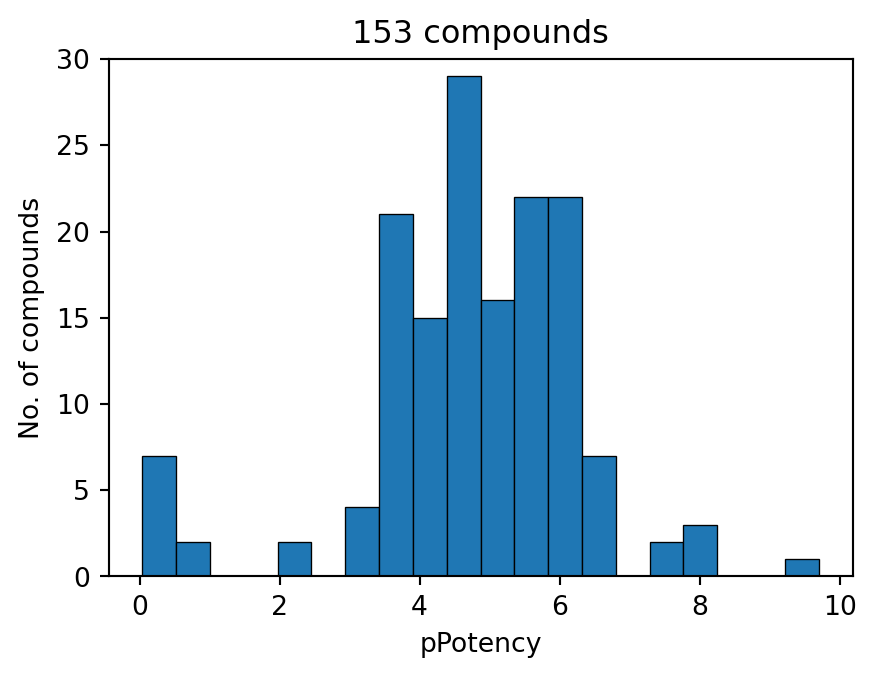

In [196]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [197]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [198]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [207]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=120, 
    random_state=42
)


After cleaning NaN values, reset the indices

In [208]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 153 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [209]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.46
  RMSE: 1.01
  R²:   0.58
Test Set:
  MAE:  0.74
  RMSE: 1.28
  R²:   0.33

Best params (sample): [{'C': 5, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}]
CPU times: user 133 ms, sys: 53.1 ms, total: 186 ms
Wall time: 3.13 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Yersinia_pestis_bestMACAW//YersiniaPestis_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Yersinia_pestis_bestMACAW//YersiniaPestis_CV_TrTs.png


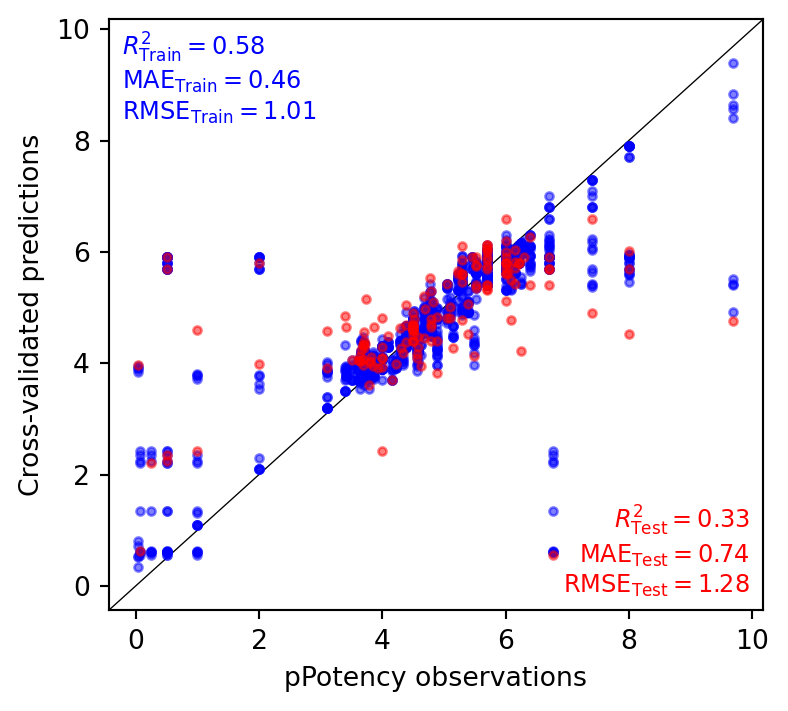

In [210]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/YersiniaPestis_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

Training samples: 122
Test samples: 31
Feature dimensions: 45

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 10
  epsilon: 0.3
  kernel: rbf

Best CV MAE (on training folds): 0.70

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.64            0.25            0.39           
MAE        0.40            0.90            0.50           
RMSE       0.88            1.60            0.72           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Yersinia_pestis_bestMACAW//YersiniaPestis_fullData_TrTs.svg
Saved: /mnt/data.ese/nf

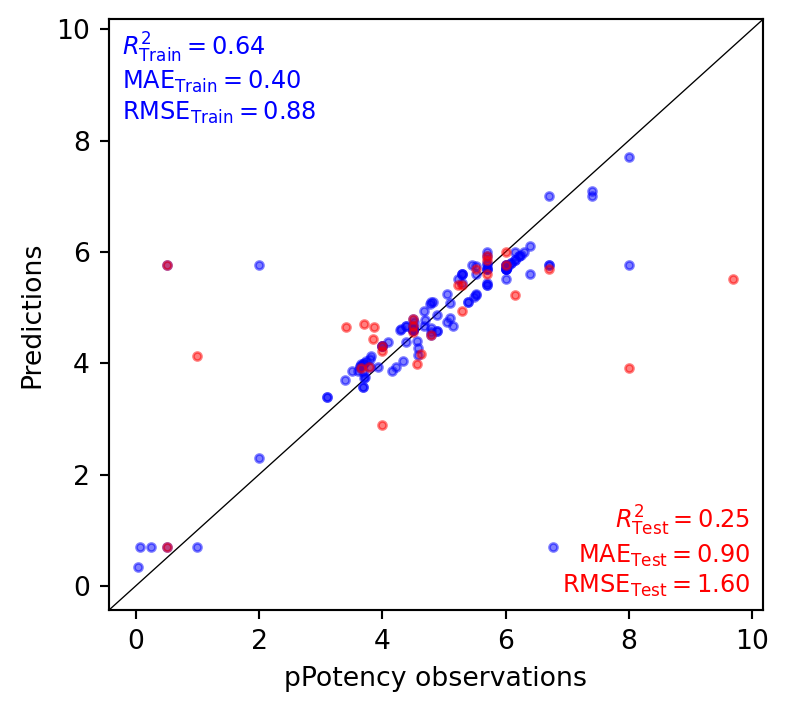

CPU times: user 1.77 s, sys: 70.9 ms, total: 1.84 s
Wall time: 2.22 s


In [211]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)


# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/YersiniaPestis_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [254]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibacterialsData.shape}")

smiles_train = YersiniaPestisData_chEMBL.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibacterialsData['Canonical_SMILES'] = EnamineAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibacterialsData_filtered = EnamineAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibacterialsData = EnamineAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibacterialsData.shape}")
print(f"Removed {EnamineAntibacterialsData.shape[0] - EnamineAntibacterialsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntibacterialsData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 92
Filtered Enamine data shape for validation: (32000, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 32000


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.60,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.50,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.01,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.70,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.70,4,https://real.enamine.net/public-enum-files/Z15...


Load pre-trained models for very large data sets or

Generate MACAW embeddings

In [255]:
smi_lib_EnamineDataset_wMACAW = mcw.transform(smi_lib_EnamineDataset)

# Create column names
num_features = smi_lib_EnamineDataset_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_EnamineDataset = pd.DataFrame(smi_lib_EnamineDataset_wMACAW, columns=column_names, index=smi_lib_EnamineDataset.index)
# Then add SMILES as first column
SMILES_lib_EnamineDataset.insert(0, 'SMILES', smi_lib_EnamineDataset)
# Save to CSV
SMILES_lib_EnamineDataset.to_csv(os.path.join(saveDir, "YersiniaPestis_EnamineDataset_wMACAW.csv"), index=False)
SMILES_lib_EnamineDataset

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,-0.021069,0.098763,-0.051459,0.012920,-0.137158,0.014809,0.073406,-0.046835,0.036903,...,0.017519,-0.041752,-0.031268,-0.109136,0.211099,-0.057961,0.134626,0.042436,-0.102272,-0.166010
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,-0.031757,0.146120,-0.002045,-0.000881,-0.108015,0.028097,0.113283,-0.029026,0.028547,...,0.021487,-0.014217,0.041951,-0.047335,0.185792,0.019787,0.103776,-0.029497,-0.133731,-0.165766
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,-0.026719,0.095338,-0.042676,0.012044,-0.115137,0.002612,0.062529,-0.053632,0.018360,...,-0.035447,-0.122224,-0.071547,-0.169898,0.068212,0.096130,0.041175,0.020300,-0.123920,-0.146696
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,0.021264,0.083723,-0.046360,-0.042037,-0.070667,0.000252,0.107403,-0.067945,-0.011504,...,-0.018032,-0.066746,-0.106992,-0.063912,0.031511,0.047468,-0.042424,0.113811,-0.022560,-0.052175
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,0.048563,0.100894,-0.021535,-0.036305,-0.106970,-0.046880,0.104293,-0.057069,0.025047,...,-0.026334,-0.024016,-0.091945,0.066581,-0.016215,0.010468,-0.000865,-0.020751,-0.040217,0.000449
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,-0.027742,0.180500,-0.025869,-0.008893,-0.114236,0.011816,0.055114,-0.048404,0.093066,...,0.032934,-0.071945,0.045262,-0.082770,0.115266,-0.041493,0.158420,-0.066327,-0.178801,-0.261721
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,-0.060418,0.151702,-0.065570,-0.000582,-0.068126,-0.028556,0.072185,-0.096116,0.065652,...,0.007584,-0.021909,0.036248,0.027680,0.091549,0.083298,0.081229,-0.103742,0.069567,-0.059140
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,-0.064010,0.165687,-0.011241,0.020457,-0.080818,-0.014252,0.060990,-0.012623,0.098346,...,0.003844,-0.074536,0.067335,-0.022053,0.055408,0.054274,0.001180,-0.000585,-0.000388,-0.023348
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,-0.032485,0.128069,-0.004578,0.051462,-0.135973,-0.006152,0.075356,-0.029891,0.055385,...,-0.028229,-0.020080,0.005876,-0.036918,0.150229,-0.062495,0.053476,-0.032199,-0.303579,-0.156146


Predict pPotency

Add predictions to dataframe

In [36]:
EnamineAntibacterialsData_predicted = EnamineAntibacterialsData.copy()
EnamineAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibacterialsData_predicted['pPotency_prediction'])

EnamineAntibacterialsData_predicted = EnamineAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,4.362326,0.000043
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,4.514020,0.000031
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,4.430947,0.000037
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,4.425943,0.000038
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,4.421228,0.000038
...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,4.615483,0.000024
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,4.641158,0.000023
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,4.723949,0.000019
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,4.438458,0.000036


Let us represent the predictions of both models:

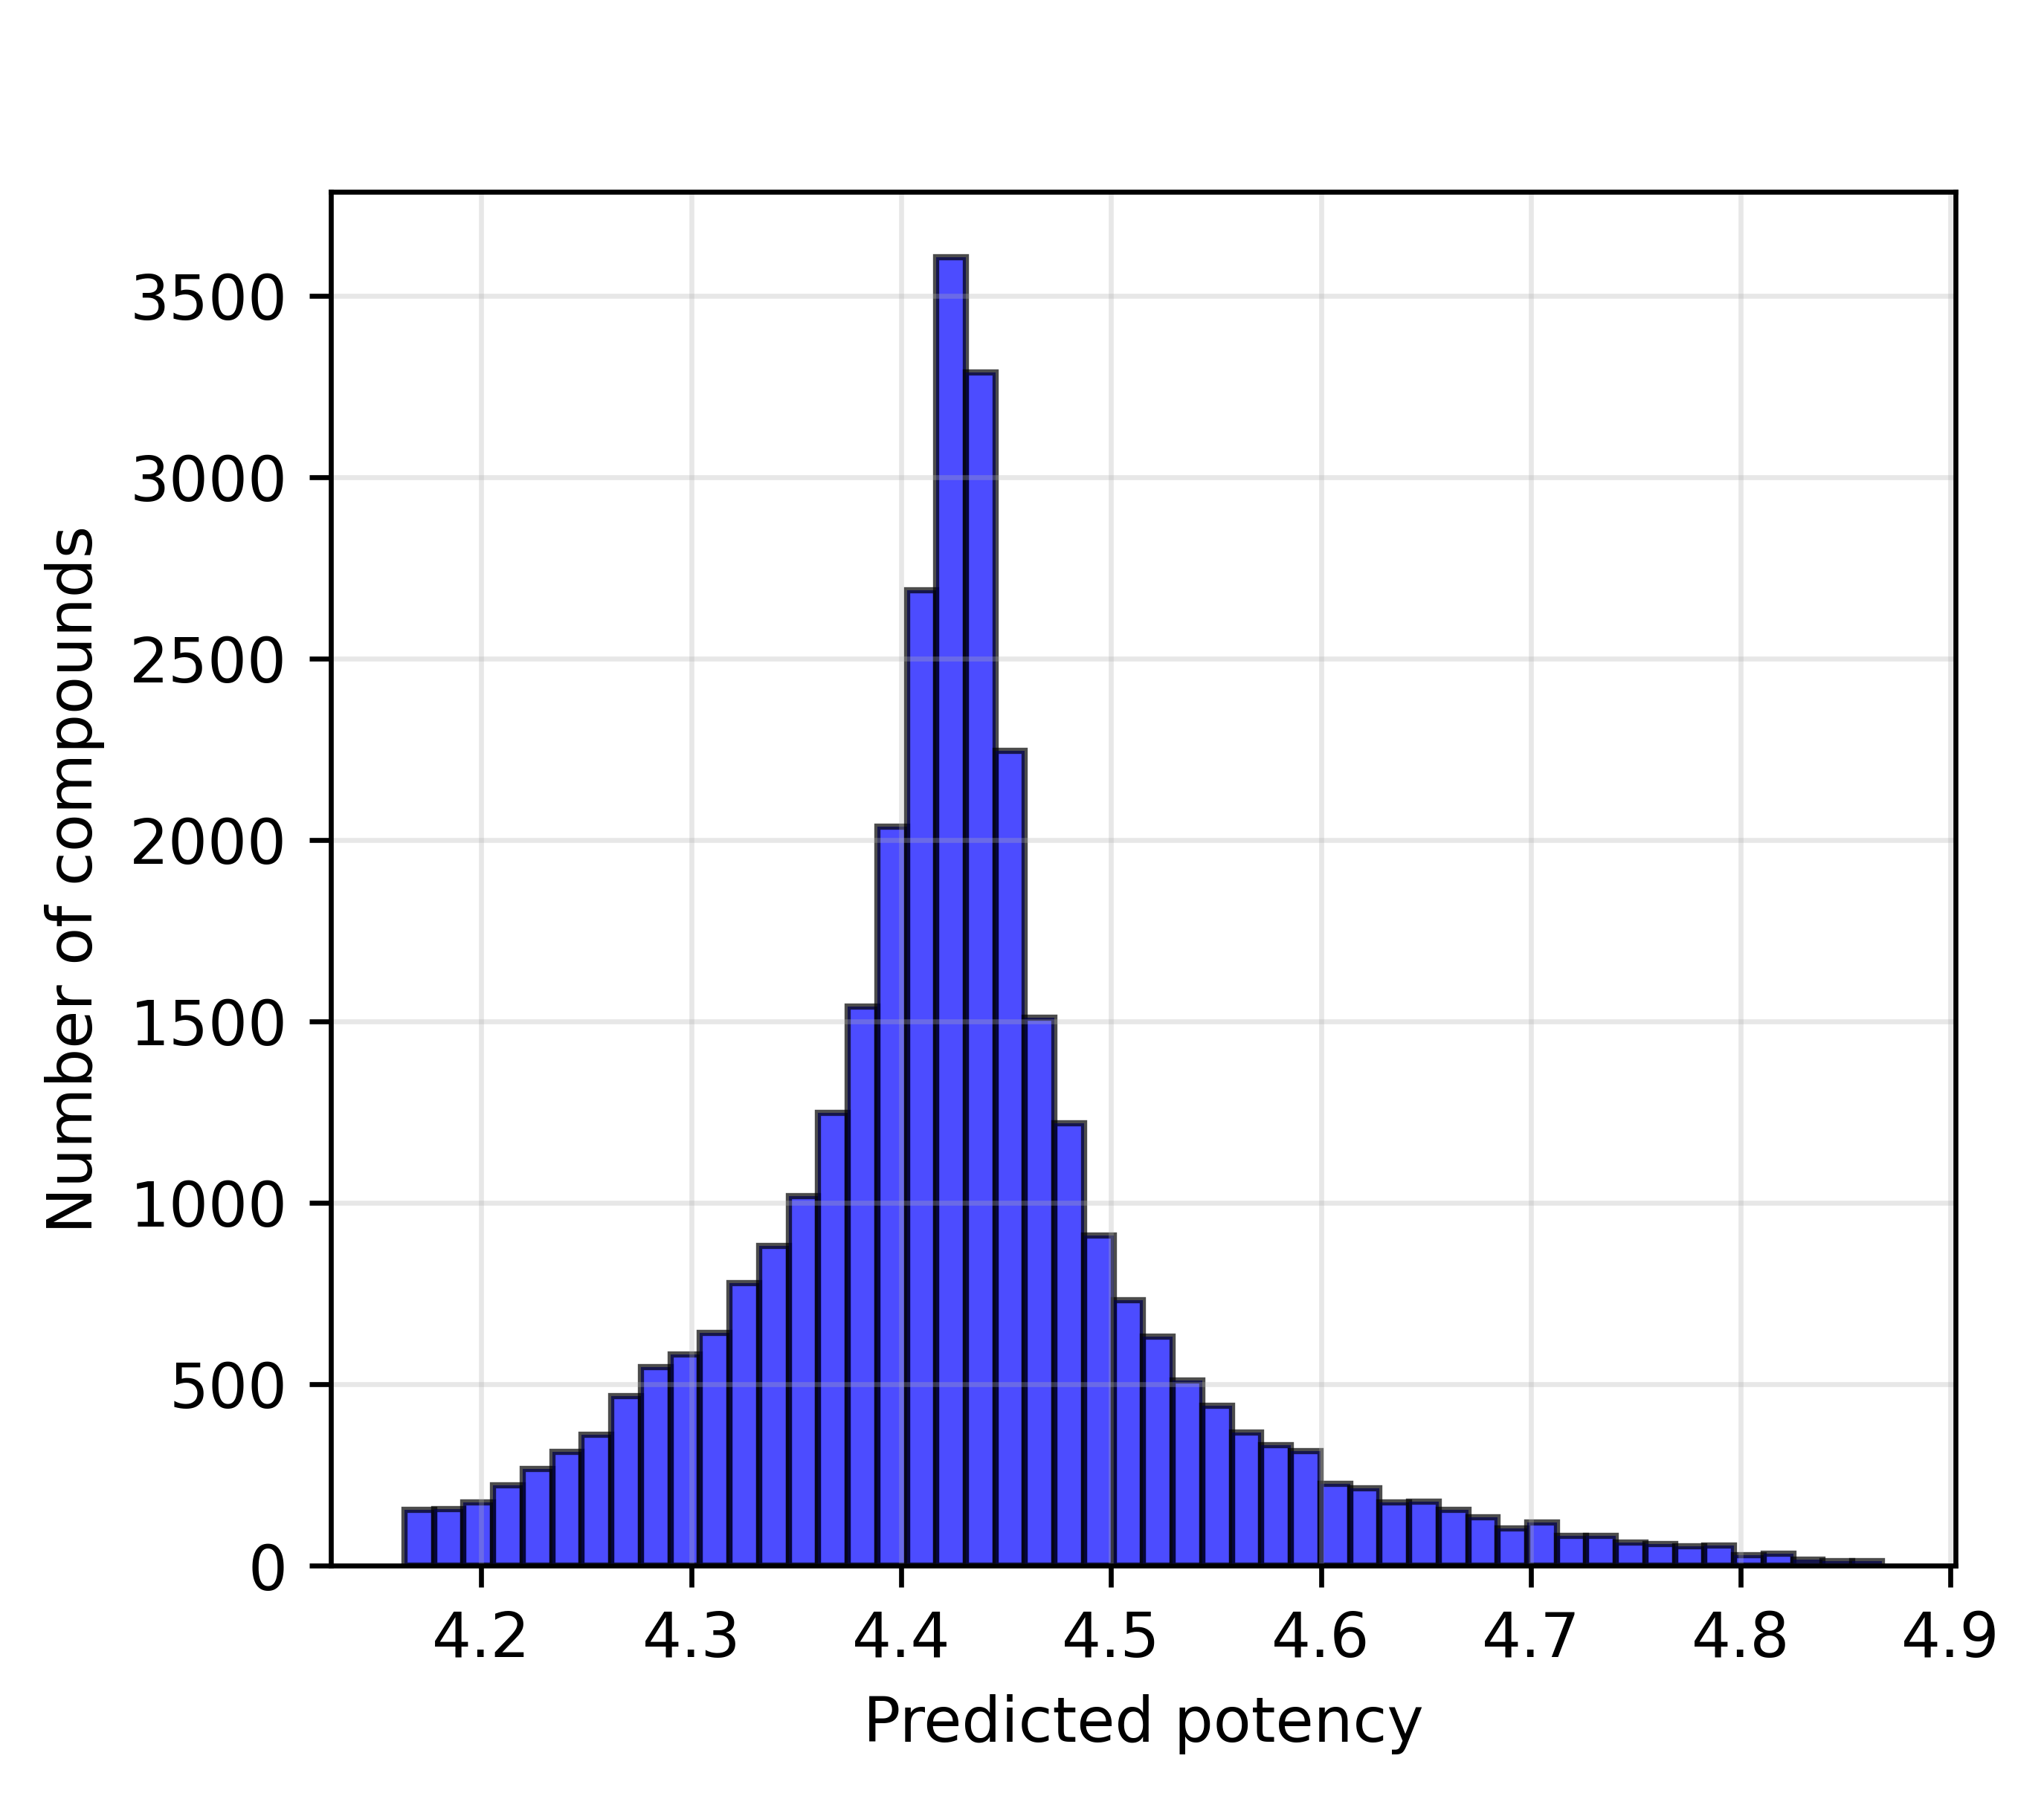

In [37]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/YersiniaPestis_enamine_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/YersiniaPestis_enamine_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [38]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 0 compounds


In [39]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher pPotency

In [40]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 4.85
Highest predicted pPotency: 4.87
Range of top 20: 4.85 - 4.87


In [41]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    4.846
  IC50:        1.424e-05 M  (14242.83 nM)

Best Values (1st ranked compound):
  pPotency:    4.867
  IC50:        1.358e-05 M  (13576.27 nM)

 Range for Top 20 Compounds:
pPotency Range:  4.846 - 4.867

IC50 Range (M):  1.424e-05 - 1.358e-05


,Rank,SMILES,pPotency_prediction,IC50 (M)
4226,1,CCNC1=NC(=NC(=N1)NC(C)(C)C)NCC,4.867,1.358e-05
6776,2,CCNC=1N=C(N=C(N1)OCC)NCC,4.866,1.362e-05
11725,3,NCC1CC(O)(CN2C[C@H]3[C@H](C(F)F)[C@H]3C2)C1,4.865,1.366e-05
4404,4,CCNC=1N=C(N=C(N1)NCC)NN,4.864,1.367e-05
4019,5,Cl.NCC1CCCN1S(=O)(=O)CC2CCCCO2,4.864,1.368e-05
3141,6,Cl.CCS(=O)(=O)N1CCC(CN)CC1,4.863,1.369e-05
4025,7,Cl.Cl.NCCN1CCN(CCC23CC4CC(CC(C4)C3)C2)CC1,4.863,1.372e-05
10371,8,CN(C)S(=O)(=O)NC1C(C)(C)C(NS(=O)(=O)N(C)C)C1(C)C,4.860,1.380e-05
28800,9,Cl.CCNS(=O)(=O)NCCNC1CCCCCC1,4.860,1.382e-05
25838,10,CC(C)(C)CCS(=O)(=O)NCC1(CC1)S(C)(=O)=O,4.859,1.385e-05


In [42]:
EnamineAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_enamine_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_enamine_predictedCompounds.svg


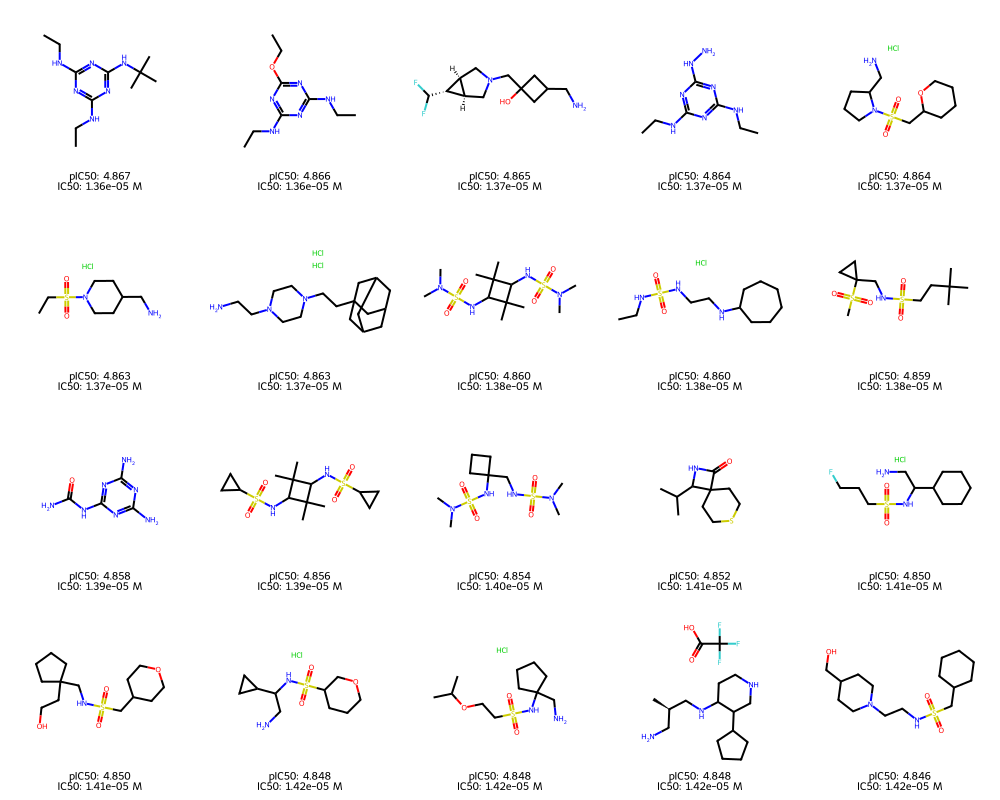

In [43]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/YersiniaPestis_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/YersiniaPestis_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to Staphylococcus (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [256]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibacterialsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibacterialsData['Canonical_SMILES'] = LCAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
LCAntibacterialsData_filtered = LCAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
LCAntibacterialsData = LCAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibacterialsData.shape}")
print(f"Removed {LCAntibacterialsData_filtered.shape[0] - LCAntibacterialsData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntibacterialsData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 92
Filtered LifeChemicals data shape for validation: (15537, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15537


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.5,236.31,oil,0.67,1.60,41.49,3,...,CHEMBL4548594,Inhibition,37.21,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.5,233.31,oil,0.69,1.51,49.25,3,...,CHEMBL4533334,Inhibition,26.56,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.5,224.28,oil,0.64,1.46,32.26,3,...,CHEMBL4542429,Inhibition,25.16,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.5,236.31,solid,0.67,1.83,41.49,3,...,CHEMBL4548594,Inhibition,37.21,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.5,222.28,solid,0.64,0.84,52.49,3,...,CHEMBL4548594,Inhibition,37.21,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN


In [257]:
smi_lib_LCAntiviralsData_wMACAW = mcw.transform(smi_lib_LCAntiviralsData)

# Create column names
num_features = smi_lib_LCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_LCAntiviralsData = pd.DataFrame(smi_lib_LCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_LCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_LCAntiviralsData.insert(0, 'SMILES', smi_lib_LCAntiviralsData)
# Save to CSV
SMILES_lib_LCAntiviralsData.to_csv(os.path.join(saveDir + "YersiniaPestis_LCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_LCAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,-0.001321,0.178318,-0.022416,0.020945,-0.056834,-0.011748,0.057700,-0.005993,0.027455,...,-0.039471,-0.091660,-0.046716,-0.133883,0.184236,0.003843,0.092975,-0.058969,-0.163802,-0.148896
1,OC1CCCN(c2ncnc3c2CCCC3)C1,0.007091,0.184293,0.002140,0.013145,-0.076913,-0.090896,0.079085,0.014345,0.085851,...,-0.022806,-0.009561,-0.027468,-0.059278,0.078456,-0.033666,0.047934,0.053572,-0.118575,-0.146739
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,-0.005980,0.179440,0.003986,-0.016069,-0.061683,-0.047398,0.054202,-0.016475,-0.013288,...,-0.023478,-0.031005,-0.008655,-0.042899,0.097742,-0.024098,0.115789,-0.055334,-0.182319,-0.184783
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,-0.007487,0.159576,-0.046352,-0.028219,-0.055521,-0.021261,0.049696,-0.057590,-0.006425,...,-0.024783,-0.113085,-0.013713,-0.093997,0.096828,0.041086,0.018310,0.017564,-0.041845,-0.176721
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,0.007401,0.179352,-0.011929,0.014884,-0.062077,-0.054276,0.064543,0.006168,0.051176,...,-0.020596,-0.065496,-0.048443,-0.074316,0.040381,-0.035708,0.055190,0.002980,-0.173992,-0.088181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,-0.019651,0.027008,0.026559,0.033733,-0.139912,0.013493,0.095475,-0.016894,-0.034685,...,-0.022608,-0.022035,-0.022006,-0.024715,0.052589,0.023075,0.027140,-0.132831,-0.122300,-0.112454
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,-0.047175,0.032916,0.003761,-0.015069,-0.103688,0.007651,0.151418,-0.075039,-0.038083,...,0.005297,-0.052648,-0.023160,0.011795,0.043622,0.005682,0.013543,0.033457,0.007532,-0.138747
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,0.093910,-0.010737,-0.003779,0.013099,-0.047480,0.102952,0.174909,-0.079599,-0.028498,...,-0.020903,-0.147262,-0.063064,-0.066589,0.070428,-0.110771,-0.052738,0.038745,-0.033568,0.088644
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,-0.145673,-0.020733,0.023813,-0.013980,-0.071268,0.031900,0.111280,-0.033270,-0.035294,...,0.035604,-0.073550,0.039865,-0.041505,0.041747,-0.029326,0.065774,0.092333,-0.036055,-0.024754


In [47]:
LCAntibacterialsData_predicted = LCAntibacterialsData.copy()
LCAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-LCAntibacterialsData_predicted['pPotency_prediction'])

LCAntibacterialsData_predicted = LCAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_LCDatasets_predicted_all.csv"), index=False)
LCAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,4.572,2.679e-05
1,OC1CCCN(c2ncnc3c2CCCC3)C1,4.618,2.410e-05
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,4.701,1.993e-05
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,4.614,2.431e-05
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,4.592,2.559e-05
...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,4.361,4.351e-05
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,4.410,3.890e-05
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,4.169,6.771e-05
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,4.323,4.750e-05


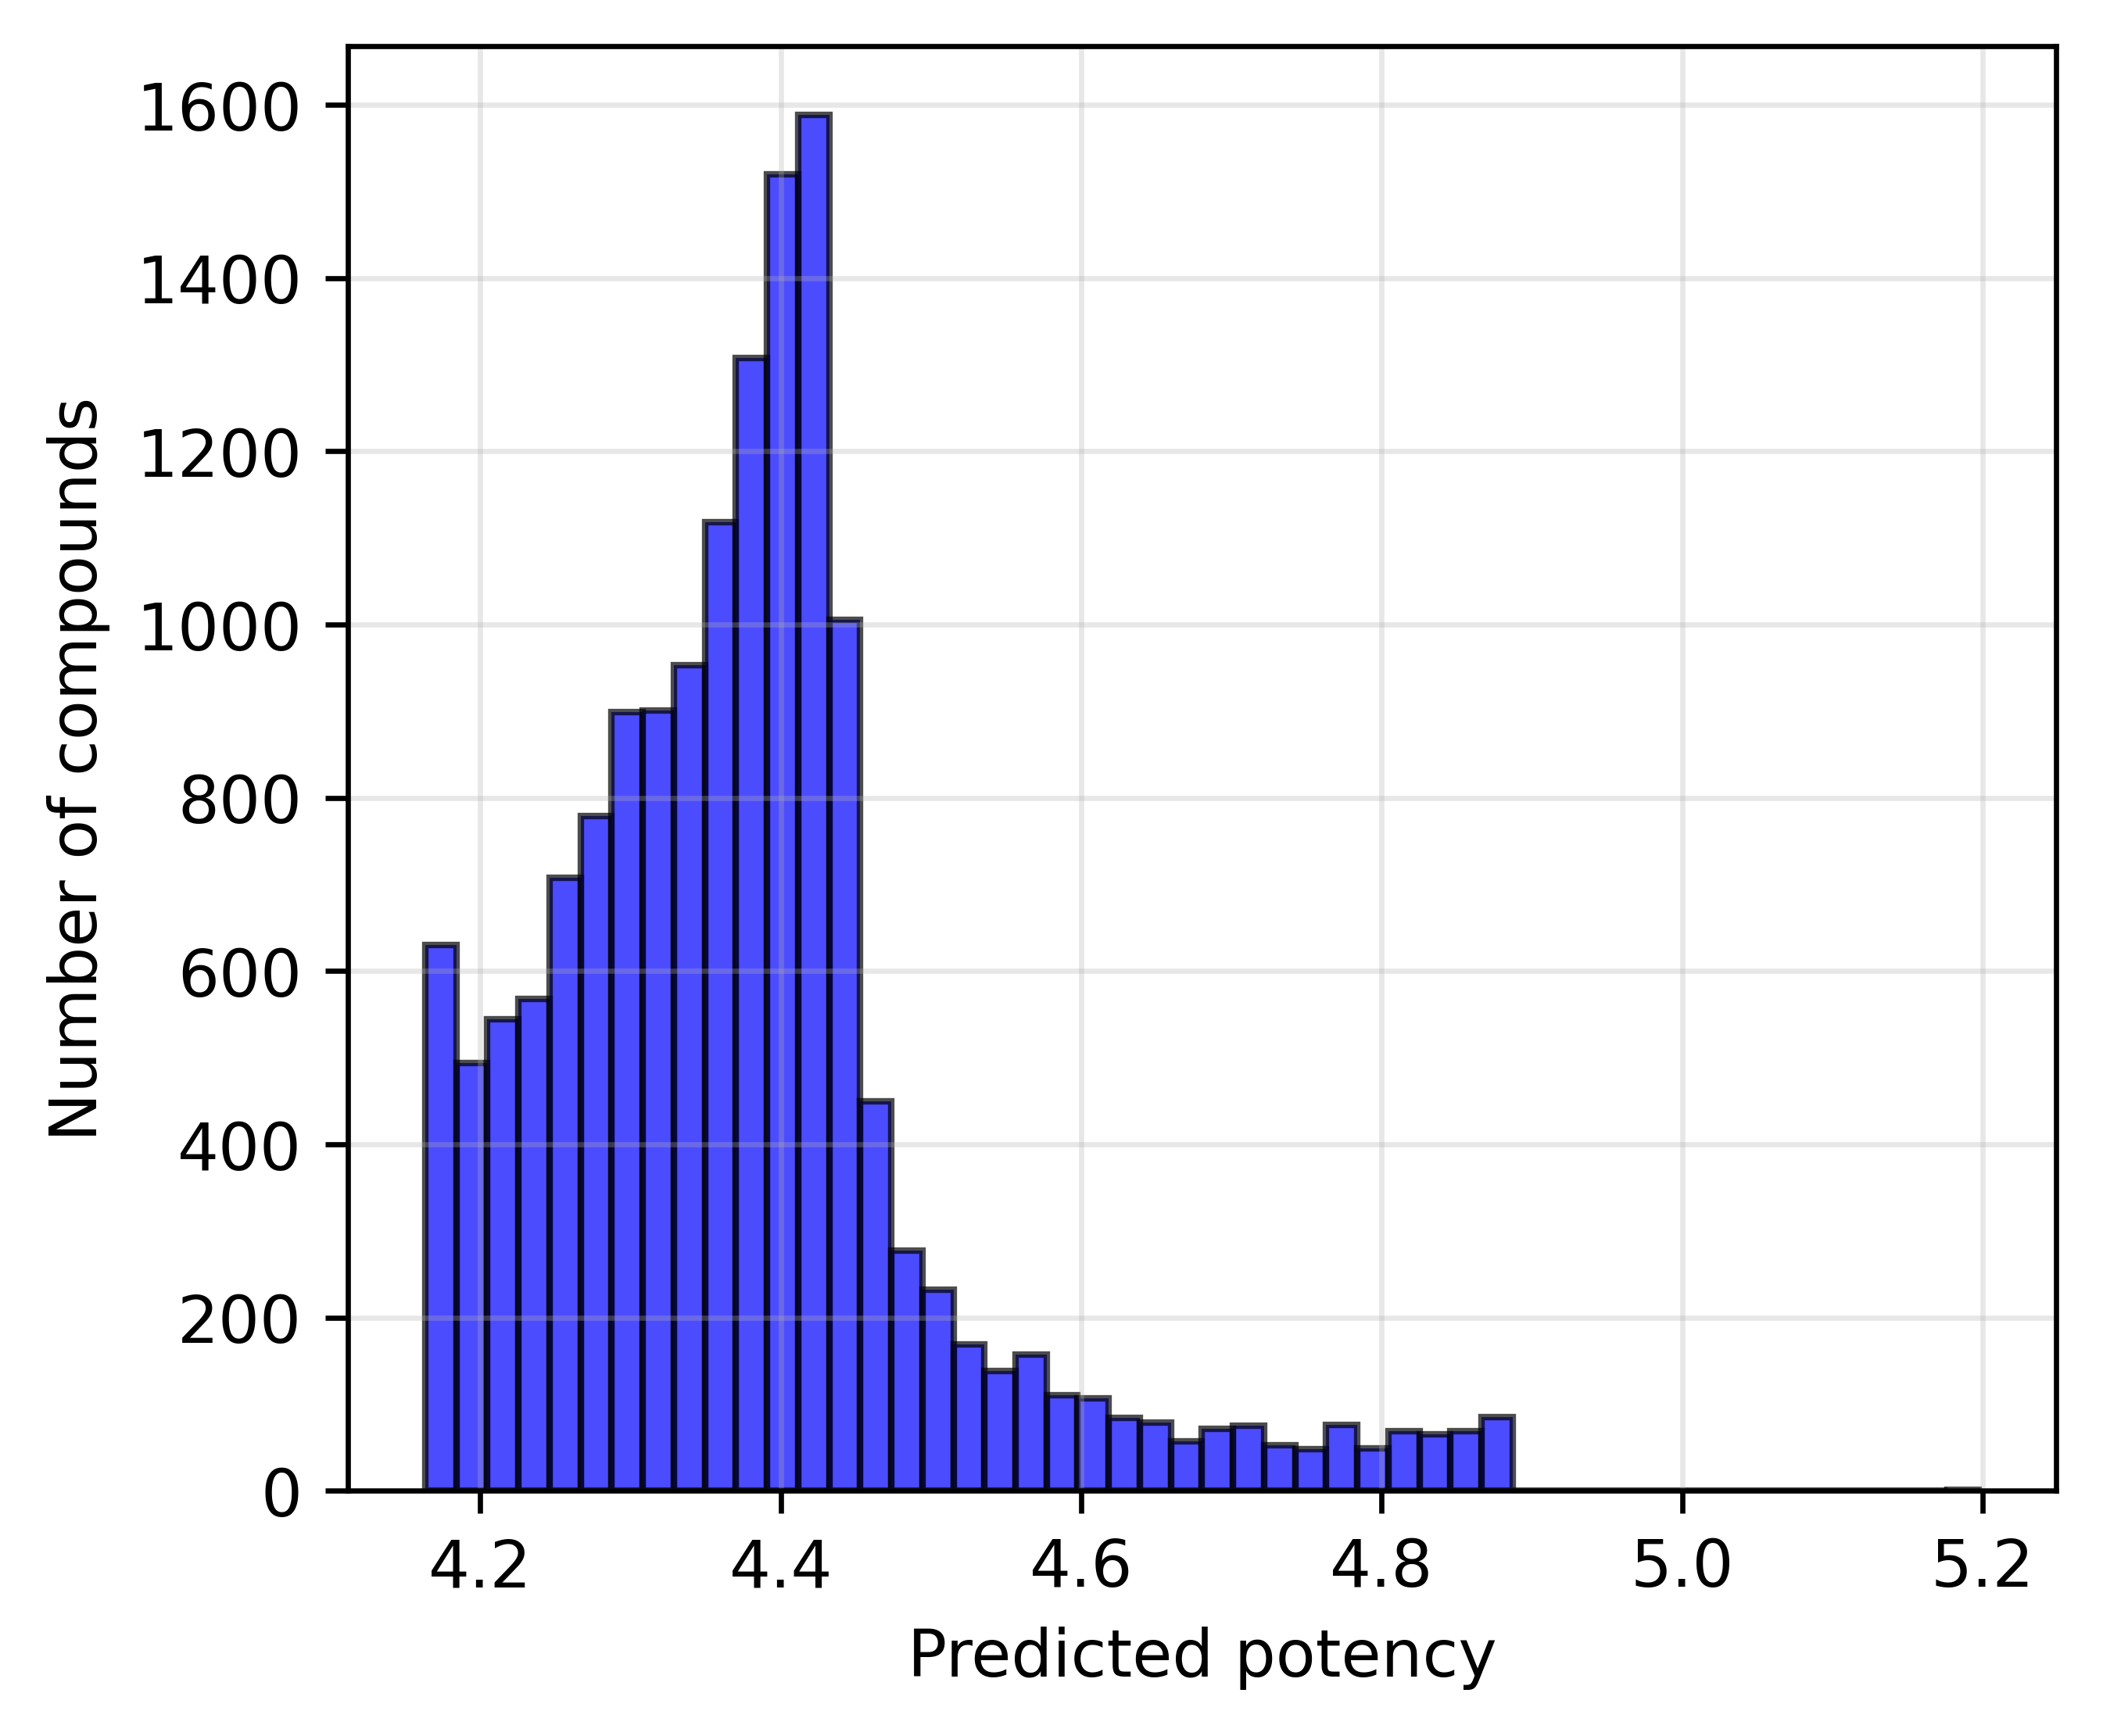

In [48]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/YersiniaPestis_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/YersiniaPestis_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [49]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 1 compounds


In [50]:
LCAntibacterialsData_final = LCAntibacterialsData.iloc[idx].copy()
LCAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibacterialsData_final = LCAntibacterialsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibacterialsData_final

,SMILES,pPotency_prediction,clogP


### Top 20 compounds with higher pPPotency

In [51]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 4.87
Highest predicted pPotency: 5.20
Range of top 20: 4.87 - 5.20


In [52]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibacterialsData_top20 = LCAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibacterialsData_top20 = LCAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    4.872
  IC50:        1.341e-05 M  (13412.37 nM)

Best Values (1st ranked compound):
  pPotency:    5.197
  IC50:        6.350e-06 M  (6350.31 nM)
Range for Top 20 Compounds:
pPotency Range:  4.872 - 5.197

IC50 Range (M):  1.341e-05 - 6.350e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
15414,1,Cc1ccc(C2=NN(C(=S)Nc3ccccc3)C(c3cccc([N+](=O)[...,5.197,6.350e-06
497,2,Cl.Cl.NC1CCN(CC2CC2)CC1,4.873,1.341e-05
269,3,C1CCC(N2CCNCC2)C1.Cl.Cl,4.873,1.341e-05
141,4,Cl.Cl.NC1CCN(C2CCCC2)CC1,4.873,1.341e-05
215,5,CN(C)CC1(O)CCOCC1,4.873,1.341e-05
162,6,CC1(C)CC(N)CC(O)C1,4.873,1.341e-05
320,7,CNCCN1CCCCC1,4.873,1.341e-05
9306,8,CN1CCN(CC#N)CC1,4.873,1.341e-05
219,9,CC(N)CN1CCCCCC1.Cl.Cl,4.873,1.341e-05
10680,10,NC(=O)c1ccco1,4.873,1.341e-05


In [53]:
LCAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_LCAntiviralsData_top20.csv"), index=False)
LCAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_LCDataset.svg


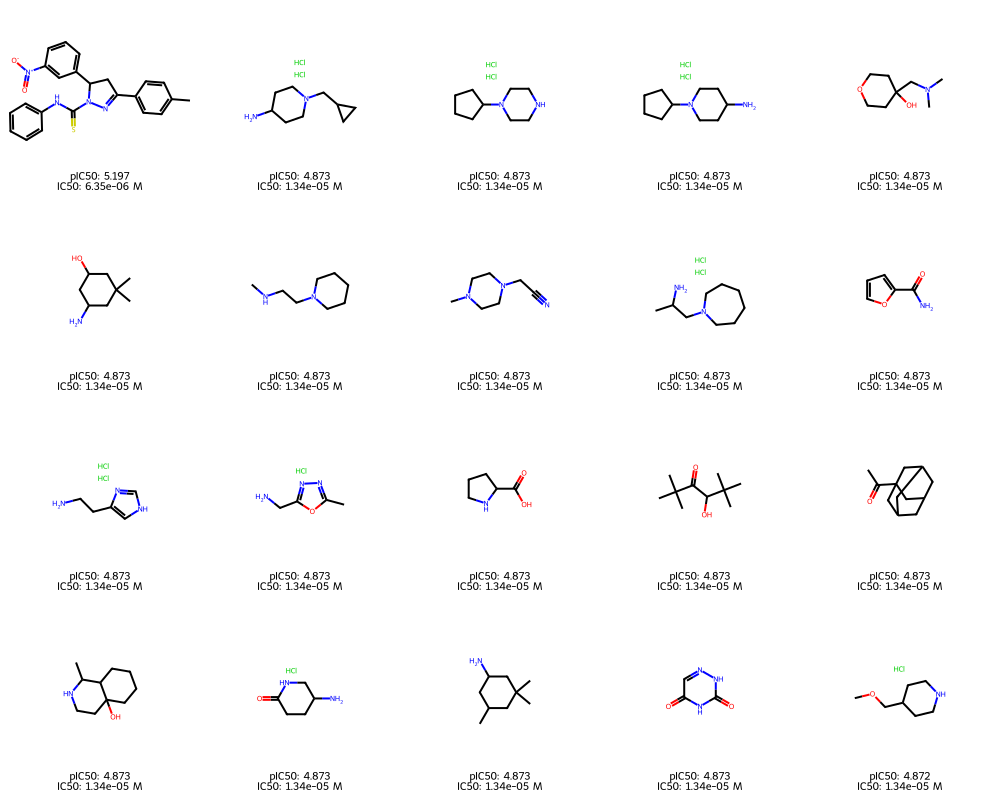

In [54]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/YersiniaPestis_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/YersiniaPestis_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [258]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 92
Filtered ChemDiv data shape for validation: (12510, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12510


,IDNUMBER,STEREO_COMMENTS,SMILE,LOGP,LOGD,LOGSW,N_ROTB,N_CHIRALS,H_ACCEPTORS,H_DONORS,PSA,WEIGHT_AVAILABLE1,CHEMNAME,SMILES,SALTDATA,SALTDATA_MOLWEIGHT
0,000L-0380,ACHIRAL,[O-][N+](c(cc1)ccc1C(Oc(cc1)ccc1-c1ccccc1)=O)=O,4.9337,4.9337,-5.1491,5.0,0.0,7.0,0.0,53.7262,34,"[1,1'-biphenyl]-4-yl 4-nitrobenzoate",O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,NaN,NaN
1,0071-0020,ACHIRAL,Cn(cc1)nc1C(N/N=C/c(cc1)ccc1OC)=O,1.2562,1.2549,-1.8429,5.0,0.0,5.0,1.0,57.7900,12,N'-[(4-methoxyphenyl)methylidene]-1-methyl-1H-...,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,NaN,NaN
2,0080-0039,RACEMIC MIXTURE,CC1(C)OC1COC(c(cc(cco1)c1c1)c1O1)=CC1=O,2.4809,2.4809,-3.1432,3.0,1.0,6.0,0.0,44.0761,113,"5-[(3,3-dimethyloxiran-2-yl)methoxy]-7H-furo[3...",CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,NaN,NaN
3,0083-0046,ACHIRAL,O=C(Cc1ccccc1)c(cc1)ccc1-c1ccccc1,4.7788,4.7788,-5.1938,4.0,0.0,2.0,0.0,12.9422,985,"1-([1,1'-biphenyl]-4-yl)-2-phenylethan-1-one",O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,NaN,NaN
4,0089-0027,ACHIRAL,O=C(c1cccc(C(Nc(cc2)ccc2Oc2ccccc2)=O)c1)Nc(cc1...,7.2932,7.2924,-6.2937,10.0,0.0,6.0,2.0,59.9163,4,"N~1~,N~3~-bis(4-phenoxyphenyl)benzene-1,3-dica...",O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12505,Z601-8334,ACHIRAL,Nc1nc(Nc(cccc2)c2F)nc2ccccc12,3.4153,3.0970,-3.6406,2.0,0.0,2.0,3.0,48.5700,460,"N~2~-(2-fluorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.4606
12506,Z601-8612,ACHIRAL,CNc1nc(Nc(cccc2)c2F)nc2ccccc12,4.0191,3.2295,-4.1598,3.0,0.0,2.0,2.0,39.1697,841,N~2~-(2-fluorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.4606
12507,Z601-8674,ACHIRAL,Nc1nc(Nc(cccc2)c2Cl)nc2ccccc12,3.6859,3.2685,-3.9047,2.0,0.0,2.0,3.0,48.5700,336,"N~2~-(2-chlorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2Cl)nc2ccccc12,NaN,NaN
12508,Z601-9100,ACHIRAL,CNc1nc(Nc(cccc2)c2Cl)nc2ccccc12,4.2898,3.3499,-4.2788,3.0,0.0,2.0,2.0,39.1697,558,N~2~-(2-chlorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,HCl,36.4606


In [259]:
smi_lib_ChemDivAntiviralsData_wMACAW = mcw.transform(smi_lib_ChemDivAntiviralsData)

# Create column names
num_features = smi_lib_ChemDivAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_ChemDivAntiviralsData = pd.DataFrame(smi_lib_ChemDivAntiviralsData_wMACAW, columns=column_names, index=smi_lib_ChemDivAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_ChemDivAntiviralsData.insert(0, 'SMILES', smi_lib_ChemDivAntiviralsData)
# Save to CSV
SMILES_lib_ChemDivAntiviralsData.to_csv(os.path.join(saveDir + "YersiniaPestis_ChemDivAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_ChemDivAntiviralsData

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,0.059497,0.085250,-0.022410,-0.030475,-0.083338,-0.063058,0.086810,-0.050318,-0.027745,...,-0.022465,-0.115116,-0.057777,-0.092770,0.171589,-0.061790,0.053773,0.056293,0.062167,-0.181968
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,0.075648,0.114266,-0.026053,-0.117645,-0.051425,0.033918,0.098375,-0.072583,-0.024356,...,0.023164,-0.146778,-0.022058,-0.087600,0.073177,-0.083480,0.015339,0.026882,-0.078343,-0.158804
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,0.001241,0.133997,-0.053262,-0.049792,-0.104491,0.012692,0.075170,-0.122961,0.009274,...,0.026597,-0.101685,0.017607,-0.148214,0.216137,-0.117265,0.166099,0.014619,-0.072626,-0.249783
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,0.083241,0.094899,-0.000856,-0.056454,-0.063781,-0.085394,0.139605,-0.074898,-0.062061,...,-0.012734,-0.057815,-0.062768,0.041227,0.038037,-0.007557,0.006588,-0.068318,-0.072093,-0.094744
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,0.002239,0.028211,-0.013030,-0.008984,-0.068836,0.021507,0.125704,-0.078776,-0.047453,...,-0.060174,-0.051489,0.009250,-0.015658,0.018522,-0.060581,0.094598,-0.065117,-0.045927,-0.214998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,0.106329,0.105069,-0.009564,-0.126560,-0.058035,-0.121850,0.133765,-0.046374,-0.065447,...,0.010427,-0.132673,0.098438,-0.017160,0.136882,0.007859,0.044316,-0.033631,-0.094890,-0.190450
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,0.110776,0.100613,-0.004898,-0.125607,-0.055423,-0.054468,0.128465,-0.080077,-0.060959,...,0.023798,-0.124265,0.033088,-0.023799,0.098719,-0.022110,-0.079101,0.042576,0.072559,-0.112416
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,0.095829,0.103267,-0.026141,-0.129554,-0.051299,-0.106580,0.170083,-0.064797,-0.061989,...,-0.028372,-0.046044,0.061285,-0.039312,0.078785,0.053373,0.038014,-0.003278,0.000321,-0.168410
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,0.104935,0.095797,-0.019314,-0.123463,-0.045209,-0.038661,0.157588,-0.098184,-0.060461,...,-0.003745,-0.035400,0.023880,-0.036550,0.026254,0.029753,-0.095086,0.073406,0.143957,-0.112643


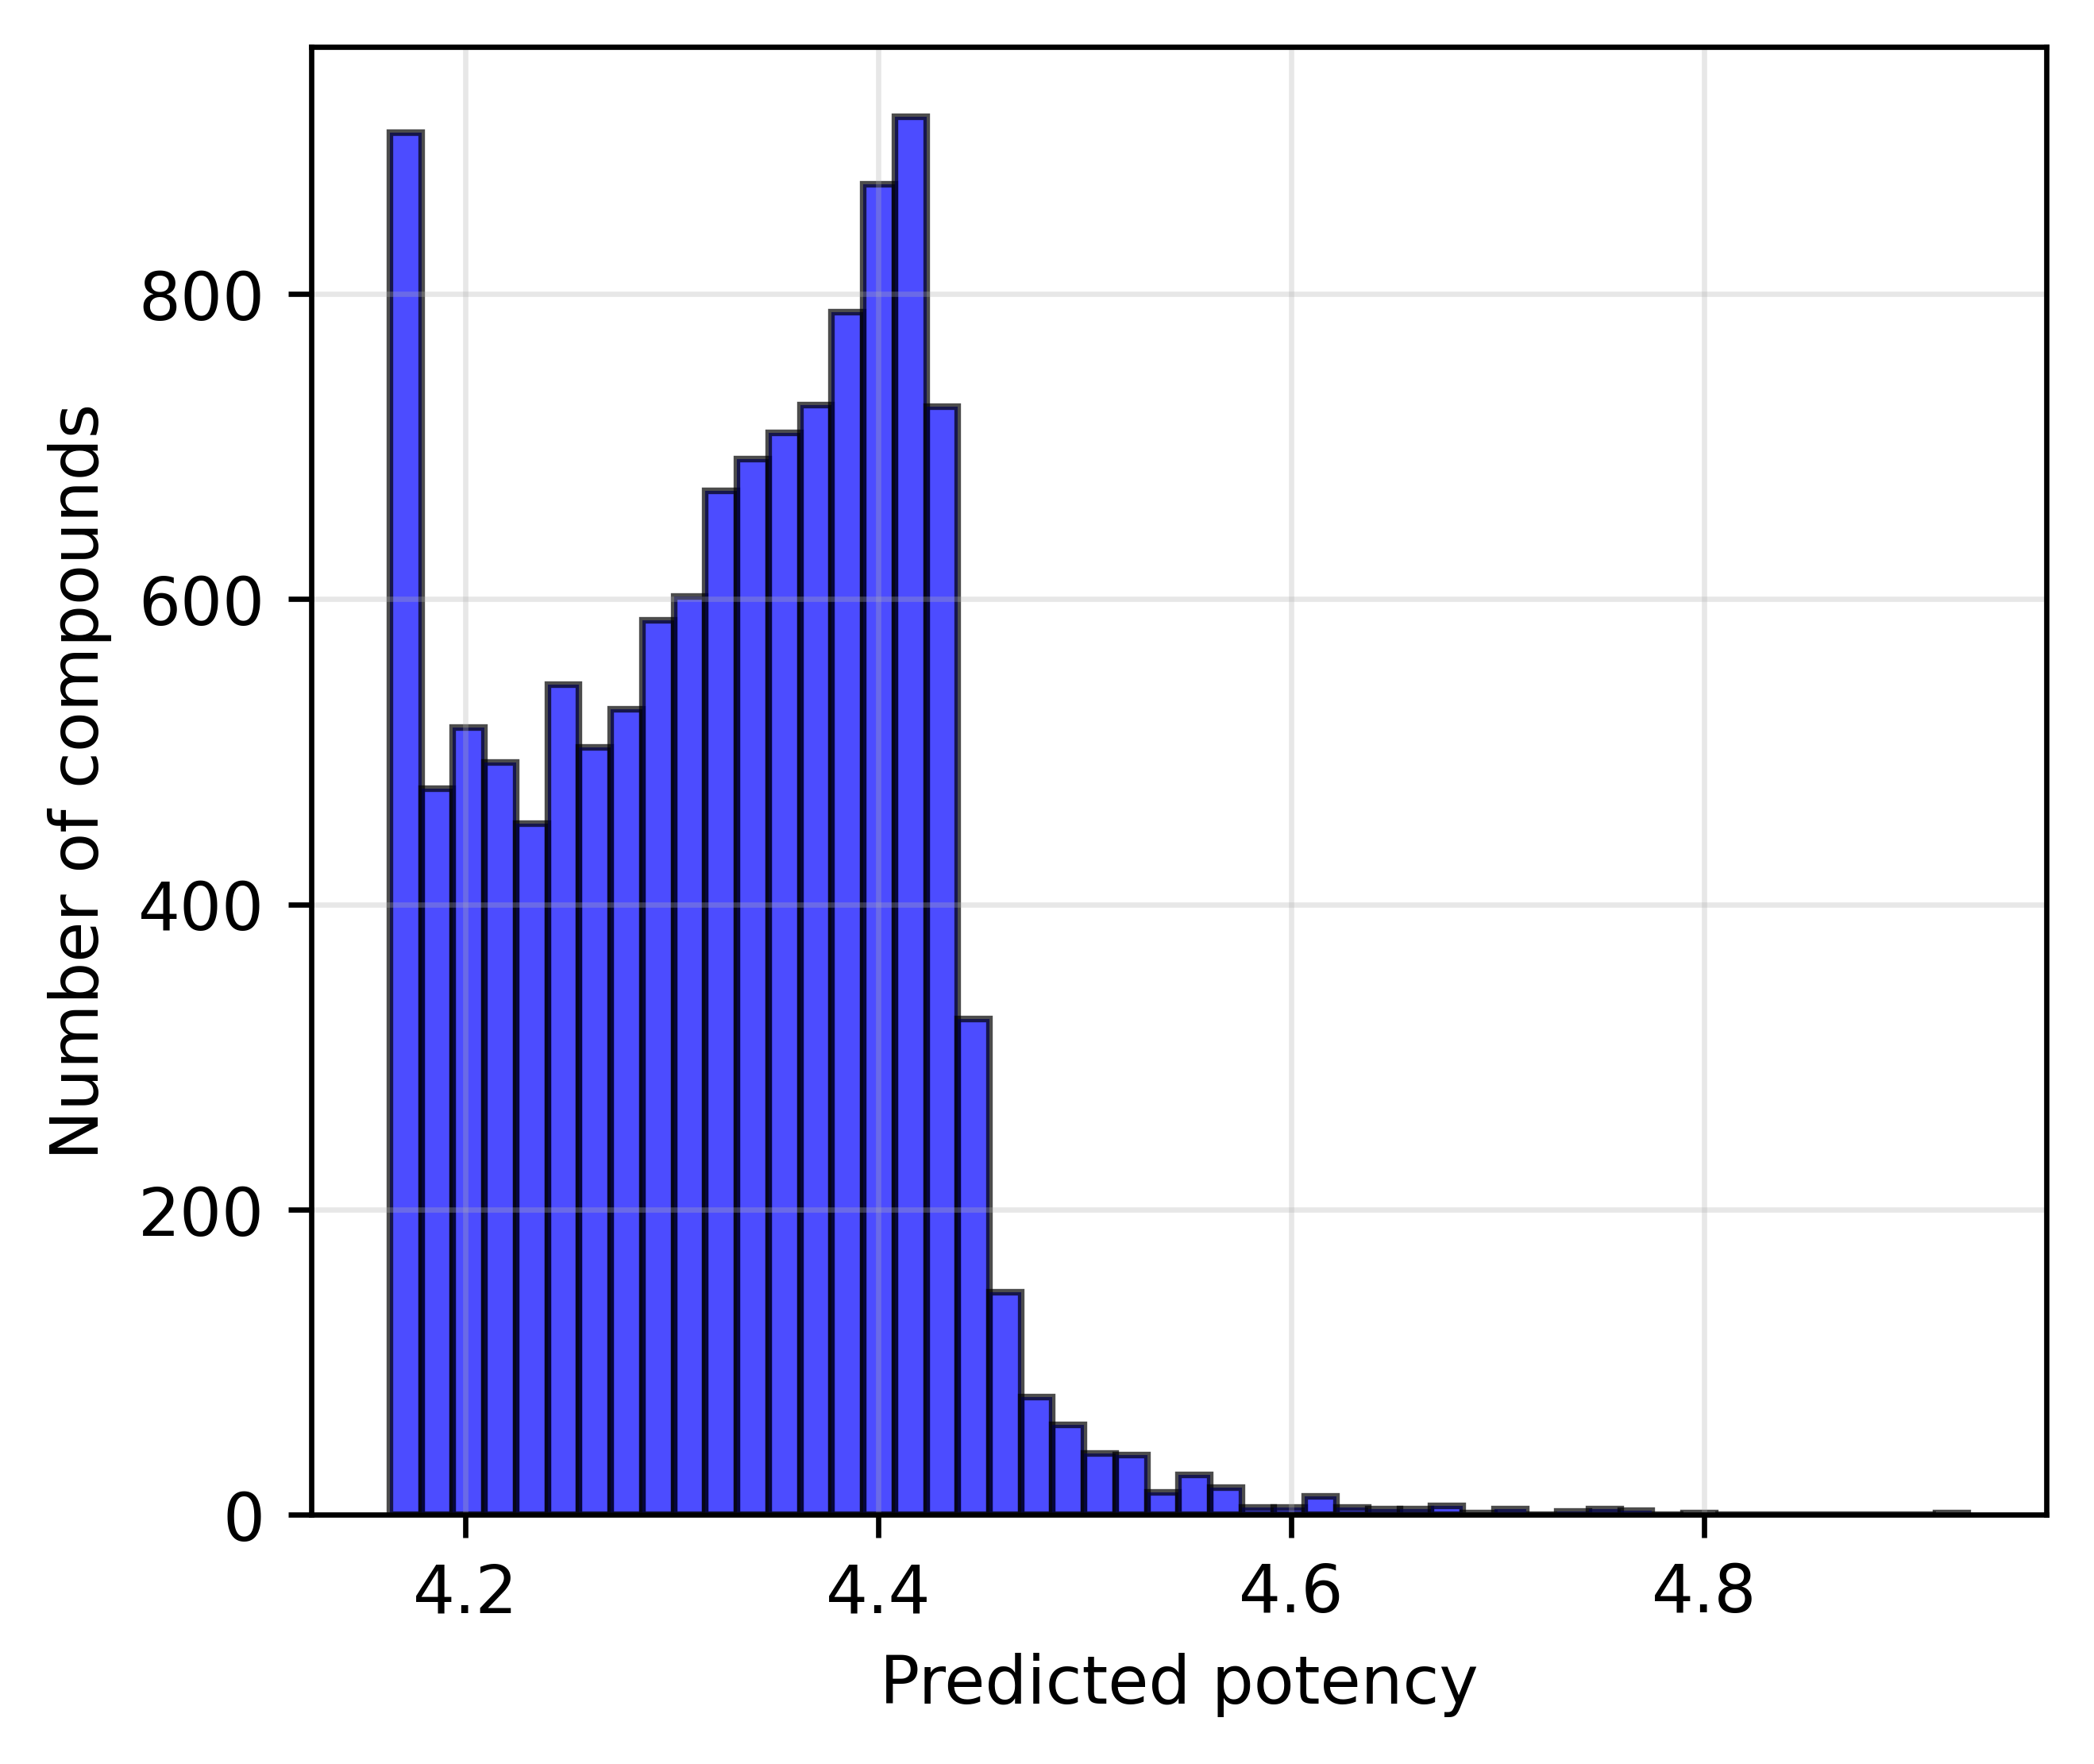

In [59]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/YersiniaPestis_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/YersiniaPestis_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [60]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 0 compounds


In [61]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

,SMILES,pPotency_prediction


### Top 20 compounds with higher pPPotency

In [62]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 4.68
Highest predicted pPotency: 4.93
Range of top 20: 4.68 - 4.93


In [63]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    4.676
  IC50:        2.107e-05 M  (21066.40 nM)

Best Values (1st ranked compound):
  pPotency:    4.928
  IC50:        1.181e-05 M  (11812.27 nM)
Range for Top 20 Compounds:
pPotency Range:  4.676 - 4.928

IC50 Range (M):  2.107e-05 - 1.181e-05


,Rank,SMILES,pPotency_prediction,IC50 (M)
2528,1,COc1ccc(OC)c(C2CC(c3ccccc3)=NN2C(=S)Nc2ccccc2)c1,4.928,1.181e-05
433,2,COC(=O)c1sc(NC(C)=O)c(C(=O)OC)c1C,4.800,1.586e-05
2846,3,CCOC(=O)c1sc(NC(C)=O)c(C#N)c1C,4.770,1.697e-05
1722,4,CCOC(=O)c1c(NC(=O)CC)sc(C)c1C,4.770,1.697e-05
4595,5,Nc1nc2ccc(OC(F)(F)Cl)cc2s1,4.767,1.708e-05
421,6,CCOC(=O)c1c(NC(C)=O)sc(C(C)=O)c1C,4.754,1.762e-05
4905,7,O=C(c1ccc(Br)cc1)c1ccco1,4.747,1.790e-05
215,8,CCOC(=O)c1sc(N)c(C(=O)OCC)c1C,4.747,1.791e-05
4882,9,CSc1nc(S)c2c3c(sc2n1)CCCC3,4.746,1.794e-05
434,10,CCC(=O)Nc1sc(C(=O)OC)c(C)c1C(=O)OC,4.741,1.815e-05


In [64]:
ChemDivAntiBioticData_top20.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiBioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_predictedCompounds_ChemDivDataset.svg


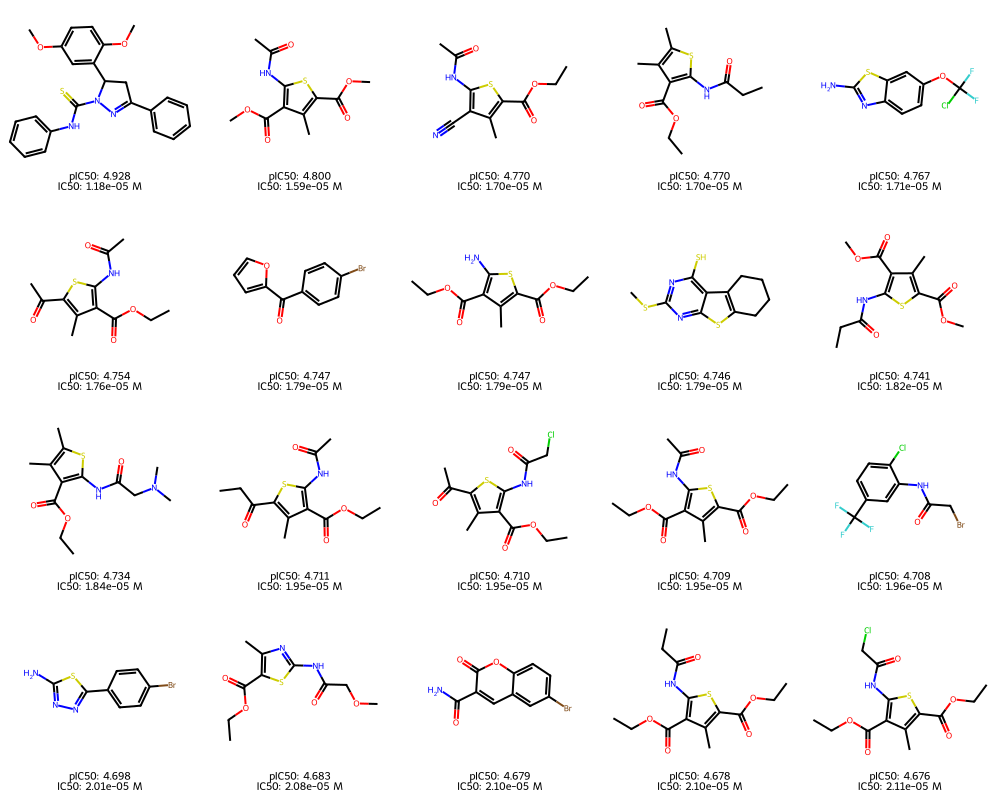

In [65]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/YersiniaPestis_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/YersiniaPestis_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.4 Checking drug likeliness of `Basidalin`

In [260]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Basidalin_SMILES='C1=C(/C(=C\C=O)/OC1=O)N'

# Dictionary of drugs and their SMILES
drugs = {
    'Basidalin': Basidalin_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

 Basidalin
  Formula: C6H5NO3
  MW: 139.11 g/mol
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Basidalin,C1=C(/C(=C\C=O)/OC1=O)N,C6H5NO3,139.11


Generate predictions

In [261]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "YersiniaPestis_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

,SMILES,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,MACAW_7,MACAW_8,MACAW_9,...,MACAW_36,MACAW_37,MACAW_38,MACAW_39,MACAW_40,MACAW_41,MACAW_42,MACAW_43,MACAW_44,MACAW_45
0,C1=C(/C(=C\C=O)/OC1=O)N,-0.021055,0.18502,-0.021196,-0.096142,-0.083797,-0.040399,0.083167,-0.059473,-0.005843,...,0.025723,-0.064661,0.011266,0.022762,0.093053,-0.027195,0.062483,0.020019,-0.089374,-0.132872


# Now we will remove duplicate from training data and re-train the model

In [66]:
# Print shape before removing duplicates
print("Before removing duplicates:", YersiniaPestisData_chEMBL.shape)

# Aggregate duplicates *within the same bacteria*
aggDF = (
    YersiniaPestisData_chEMBL.groupby(['Smiles', 'BacteriaClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
YersiniaPestisData_chEMBL_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'BacteriaClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'BacteriaClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", YersiniaPestisData_chEMBL_noDuplicates.shape)

Before removing duplicates: (153, 5)
After removing duplicates: (92, 3)


In [67]:
duplicates = YersiniaPestisData_chEMBL_noDuplicates.duplicated(subset=['Smiles'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


In [68]:
YersiniaPestisData_chEMBL_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "YersiniaPestisData_chEMBL_noDuplicates_MLready.csv"), index=False)

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [69]:
# df = YersiniaPestisData_chEMBL
Y = YersiniaPestisData_chEMBL_noDuplicates.pPotency
smiles = YersiniaPestisData_chEMBL_noDuplicates.Smiles

In [70]:
print(len(smiles))

92


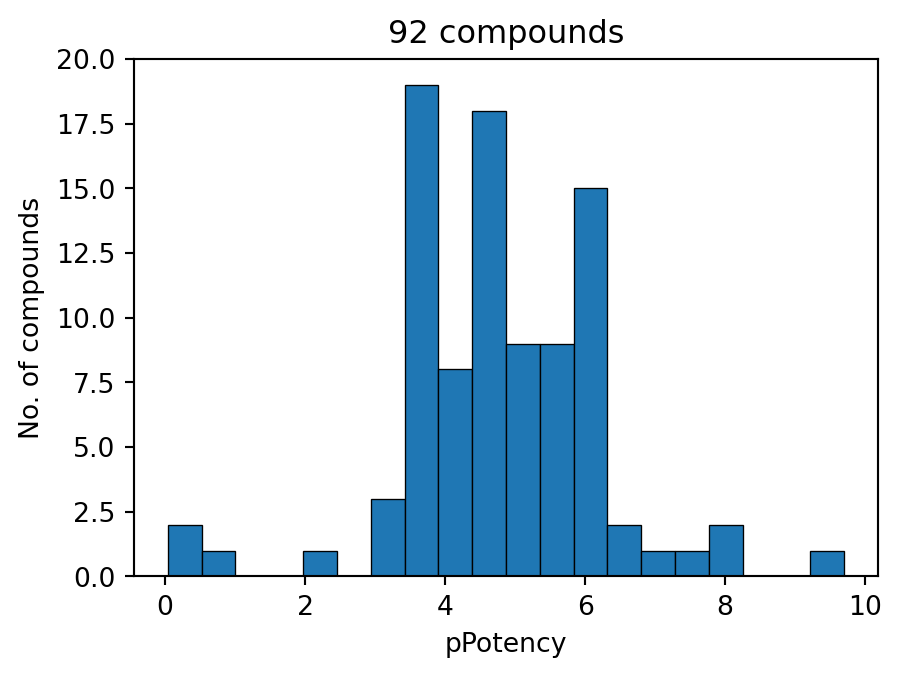

In [71]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [72]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [73]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [74]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=50, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [75]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True) 


print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 92 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### Create directory to save plot

In [76]:
save_path = saveDir + '/YersiniaPestis_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### ML predictions with Train + Test results

In [77]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.56
  RMSE: 1.00
  R²:   0.50
Test Set:
  MAE:  0.83
  RMSE: 1.38
  R²:   0.06

Best params (sample): [{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 1, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 116 ms, sys: 32.5 ms, total: 148 ms
Wall time: 2.65 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_noDuplicates_CV_TrTs.png


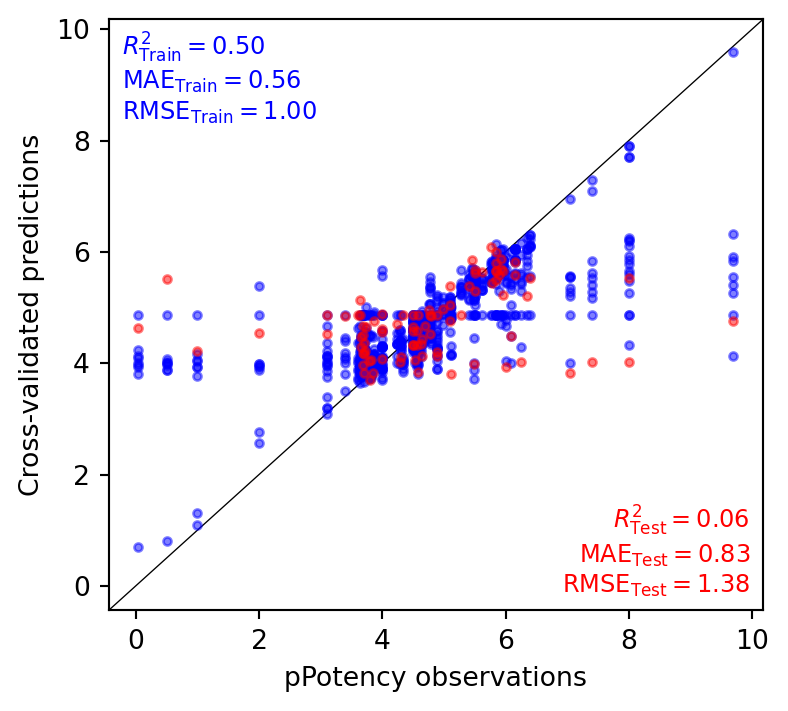

In [78]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=saveDir + '/YersiniaPestis_noDuplicates_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

Training samples: 73
Test samples: 19
Not enough Nldnmk, n_components has been set to 31
Feature dimensions: 31

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 100
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.93

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.32            -0.25           0.57           
MAE        0.71            0.70            0.01           
RMSE       1.24            1.22            0.02           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_no

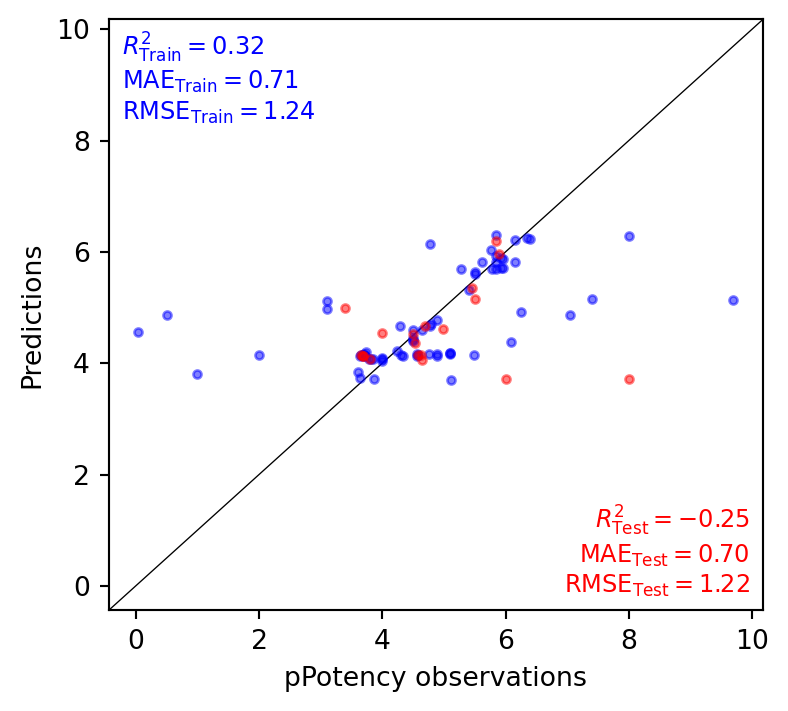

CPU times: user 1.5 s, sys: 79.5 ms, total: 1.58 s
Wall time: 1.62 s


In [79]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=45, 
    n_landmarks=50, 
    random_state=42
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)


# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=saveDir + '/YersiniaPestis_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

## 2.1 Discovery of new hits specific to all Bacteriaes (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [80]:
EnamineAntibacterialsData = pd.read_csv(dataDir + "Enamine/Enamine_Antibacterial_Library_plated_32000cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                     skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntibacterialsData.shape}")

smiles_train = YersiniaPestisData_chEMBL_noDuplicates.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntibacterialsData['Canonical_SMILES'] = EnamineAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntibacterialsData_filtered = EnamineAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntibacterialsData = EnamineAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntibacterialsData.shape}")
print(f"Removed {EnamineAntibacterialsData.shape[0] - EnamineAntibacterialsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntibacterialsData.head()

Original Enamine data shape: (32000, 11)
Number of unique SMILES in training set: 92
Filtered Enamine data shape for validation: (32000, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 32000


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,Z19065527,374.392,374.392,2.754,-4.286,0,6,111.600,6,https://real.enamine.net/public-enum-files/Z19...
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,Z1203040657,338.387,338.387,1.246,-4.006,2,5,124.500,8,https://real.enamine.net/public-enum-files/Z12...
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,Z19154552,384.449,384.449,2.021,-3.375,1,5,102.010,6,https://real.enamine.net/public-enum-files/Z19...
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,Z1509821346,346.409,346.409,1.094,-1.970,1,5,94.700,6,https://real.enamine.net/public-enum-files/Z15...
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,Z1509833014,341.768,341.768,2.254,-3.235,3,5,103.700,4,https://real.enamine.net/public-enum-files/Z15...


Load pre-trained models for very large data sets or

Generate MACAW embeddings

In [81]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (32000, 31)


Predict pPotency

In [82]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (32000,)


Add predictions to dataframe

In [83]:
EnamineAntibacterialsData_predicted = EnamineAntibacterialsData.copy()
EnamineAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-EnamineAntibacterialsData_predicted['pPotency_prediction'])

EnamineAntibacterialsData_predicted = EnamineAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,CC1=NN=C(COC(=O)C=2C=CC(=C(C2)[N+]([O-])=O)N3C...,4.507,3.113e-05
1,CC1=NC2=NC(=NN2C(C)=C1C)SCCCOC(=O)NC(N)=O,3.784,1.644e-04
2,CC=1C=CC(=CC1)S(=O)(=O)NCC(=O)OCC(=O)N2CC(C)OC...,3.873,1.339e-04
3,CC(C)N1C=NC(=C1)S(=O)(=O)NC=2C=CN(CC=3C=CC=CN3)N2,3.976,1.057e-04
4,O=C(O)CC=1C=CC(=CC1)S(=O)(=O)NC=2C=CC(Cl)=CC2O,4.051,8.892e-05
...,...,...,...
31995,CCOCCCOC(=O)C1=CC(=C(C)S1)[N+]([O-])=O,4.121,7.572e-05
31996,CC(C)C(NS(=O)(=O)CC12CCC(CC1=O)C2(C)C)C(N)=O,4.162,6.883e-05
31997,CNC(=O)CN1CCC(CC1)NS(=O)(=O)CCCC(F)(F)F,4.308,4.918e-05
31998,CCOC(=O)NC1CCCN(C1)C(=O)C2=CC(=NN2C3CC3)C(F)(F)F,3.762,1.731e-04


Let us represent the predictions of both models:

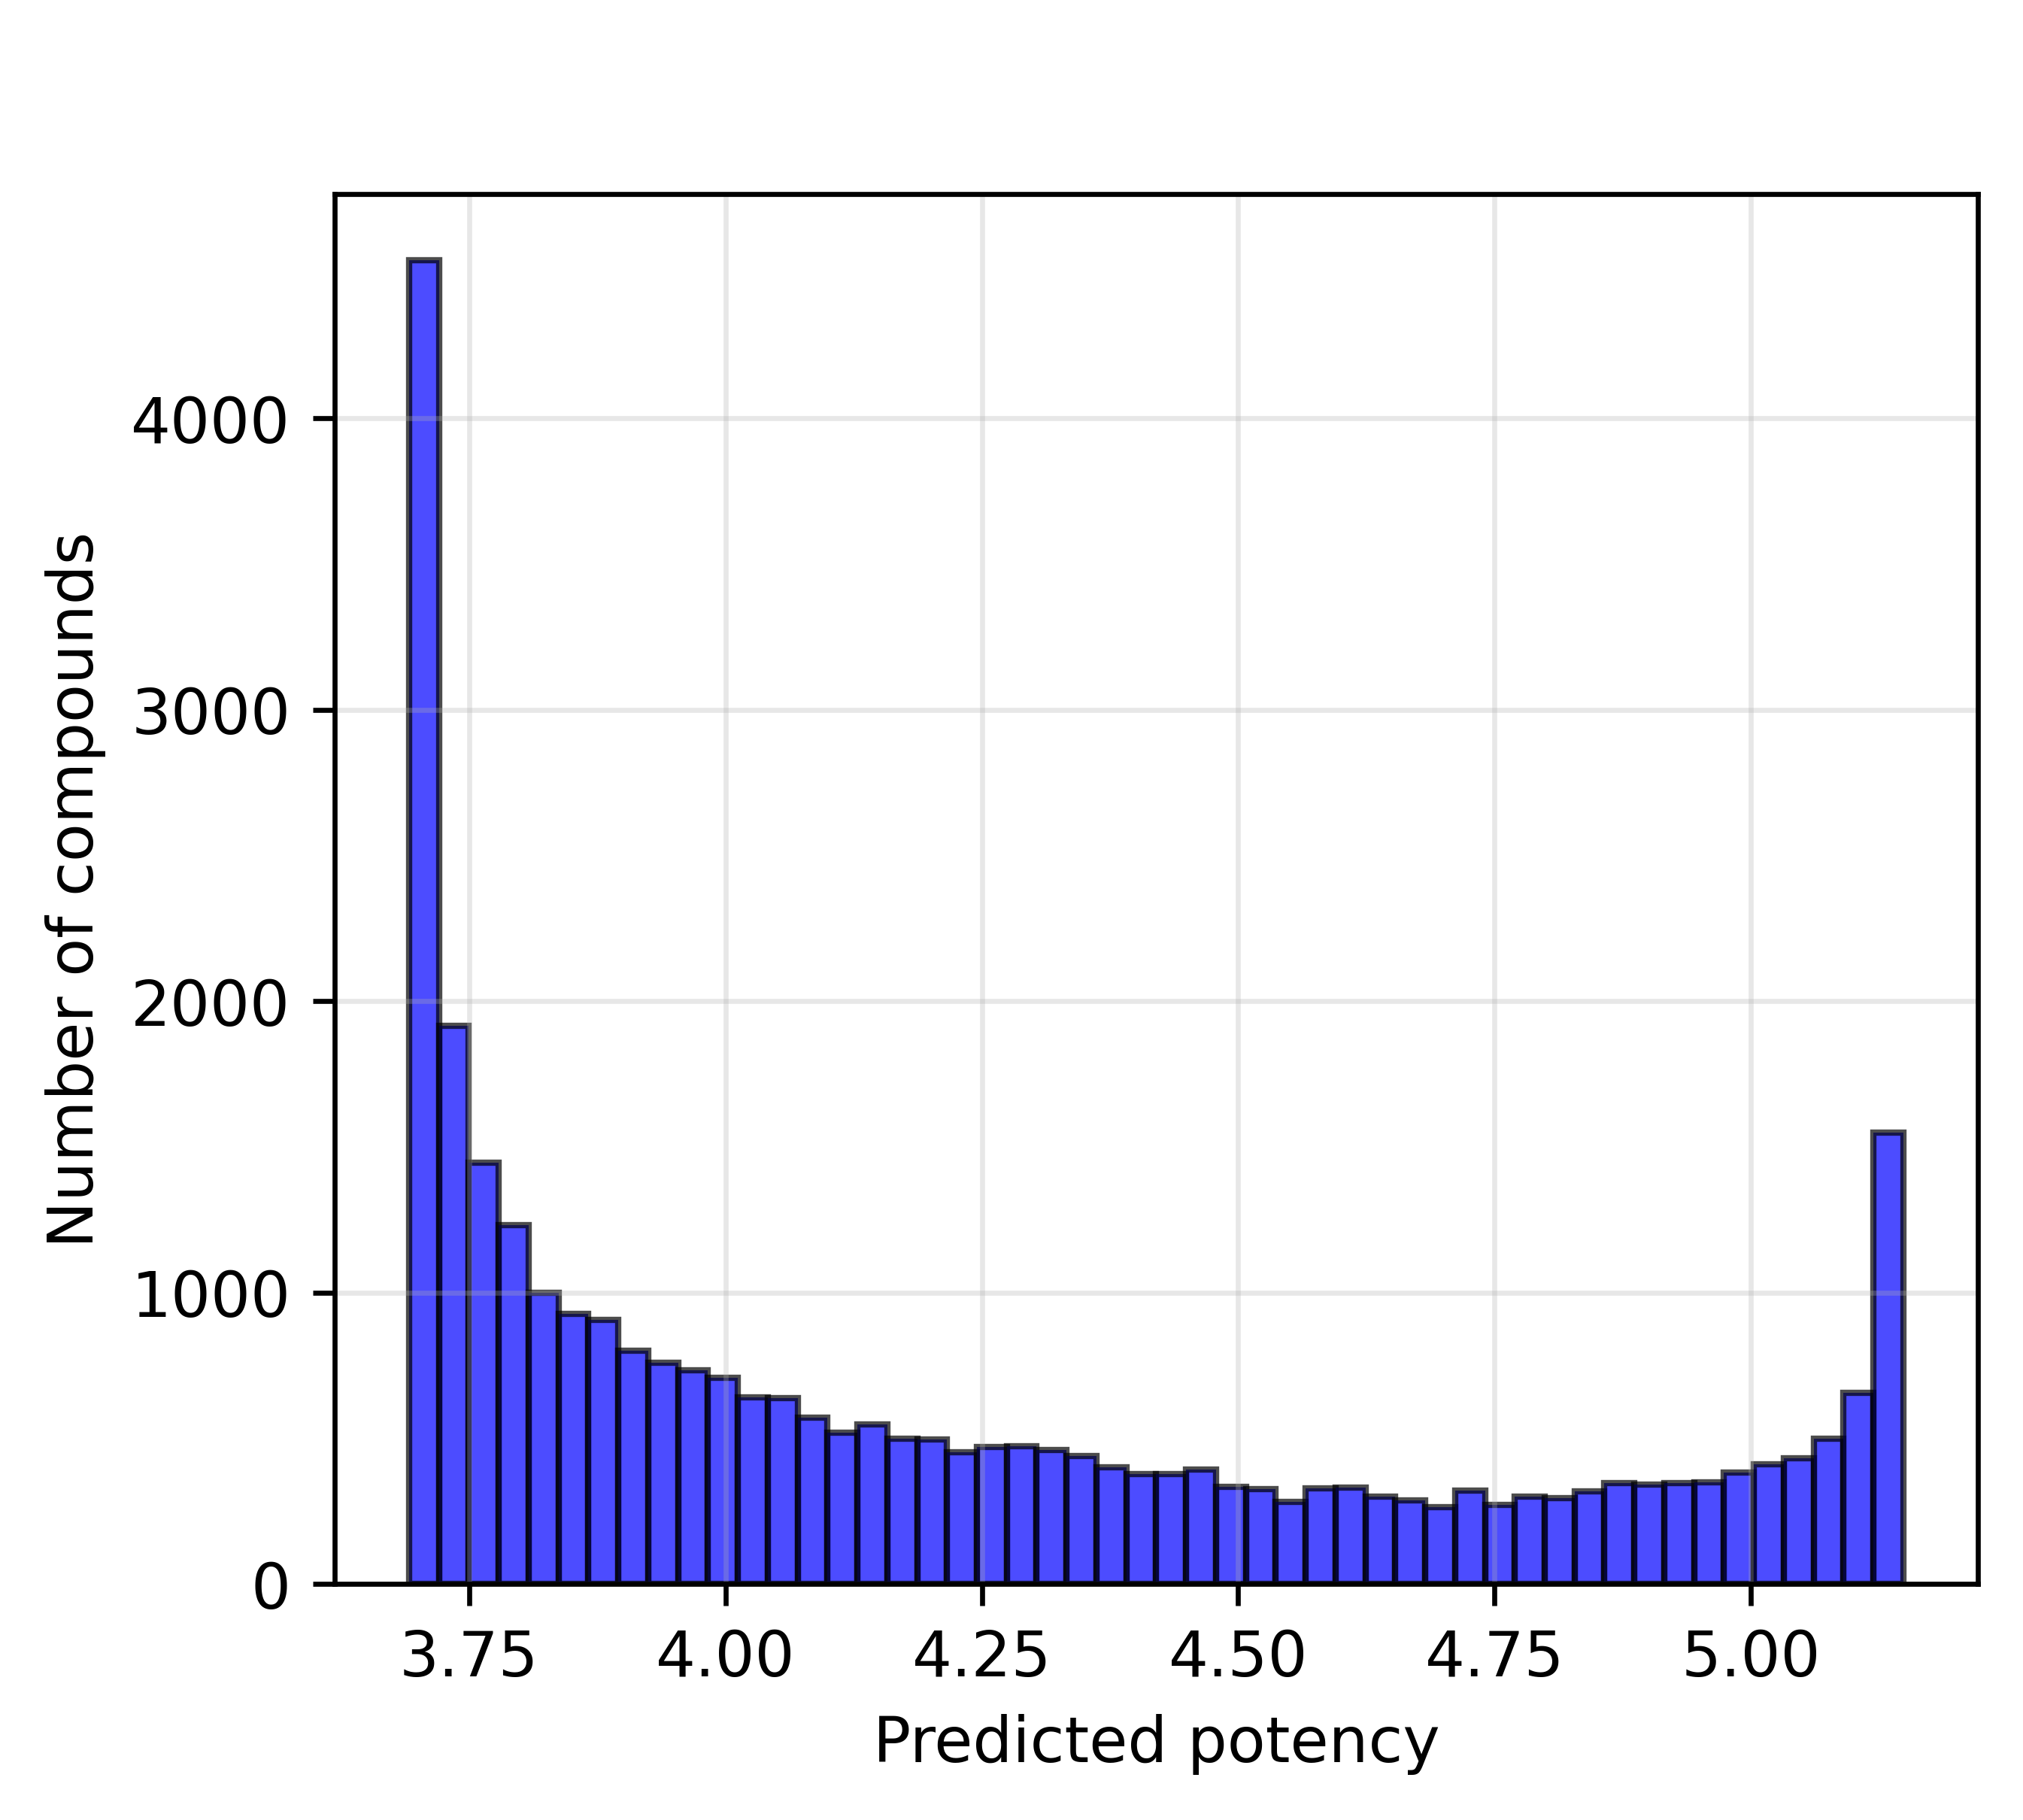

In [84]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/YersiniaPestis_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/YersiniaPestis_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [85]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 3586 compounds


In [86]:
EnamineAntibacterialsData_final = EnamineAntibacterialsData.iloc[idx].copy()
EnamineAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntibacterialsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher pPotency

In [87]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.15
Highest predicted pPotency: 5.15
Range of top 20: 5.15 - 5.15


In [88]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("\n Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntibacterialsData_top20 = EnamineAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntibacterialsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.149
  IC50:        7.100e-06 M  (7100.29 nM)

Best Values (1st ranked compound):
  pPotency:    5.149
  IC50:        7.100e-06 M  (7100.21 nM)

 Range for Top 20 Compounds:
pPotency Range:  5.149 - 5.149

IC50 Range (M):  7.100e-06 - 7.100e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
24734,1,CCOC=1C=CC(=CC1NC(=O)C2=CC=3N=C(C)C=CC3O2)[N+]...,5.149,7.100e-06
13616,2,COC(=O)C=1C(C)=C2C=CC=CC2=NC1CN(C)CC(=O)NC3=CC...,5.149,7.100e-06
18822,3,COC(=O)N(C)CC(=O)NC=1C=CC=CC1COC=2C=CC(=CC2)CC#N,5.149,7.100e-06
22890,4,COC(=O)C=1C=C(C=C(C1)[N+]([O-])=O)C(=O)N(CC2CC...,5.149,7.100e-06
2830,5,O=C(O)C(F)(F)F.CC1=CN(CC(=O)N2CC(CCN)C3=CC=CC=...,5.149,7.100e-06
22195,6,COC=1C=CC(=CC1C(=O)O)S(=O)(=O)NC2=CSC(=N2)C3=C...,5.149,7.100e-06
28900,7,CN(C(=O)CCNC=1C=CC=2C=C(C=CC2N1)[N+]([O-])=O)C...,5.149,7.100e-06
31751,8,CCOC(=O)NCCC(=O)NC=1C=CC(=CC1)C2=CN3C=CC=C(C)C...,5.149,7.100e-06
6633,9,CC1=CC=CC(OC=2C=CC(NC(=O)C=3C=COC3CN)=C(C)N2)=C1C,5.149,7.100e-06
192,10,COC=1C=CC=2CN(CCCC2C1)C(=O)C=3C=CC(=C(O)C3)[N+...,5.149,7.100e-06


In [89]:
EnamineAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_enamine_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_enamine_predictedCompounds.svg


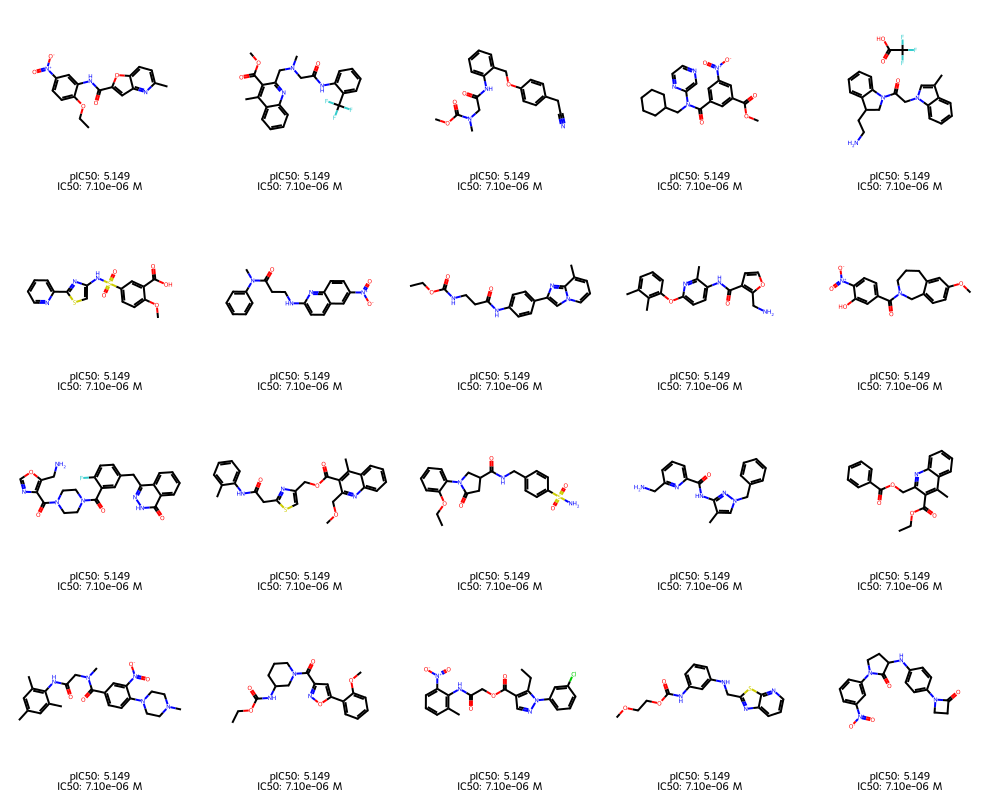

In [90]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/YersiniaPestis_noDuplicates_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/YersiniaPestis_noDuplicates_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.2 Discovery of new hits specific to this bacteria (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Life chemicals. In particular, we are interested in molecules with high predicted pPotency.

In [91]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Antibacterial_Focused_Library.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntibacterialsData = pd.DataFrame(records)

print(f"Original LifeChemicals data shape: {LCAntibacterialsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntibacterialsData['Canonical_SMILES'] = LCAntibacterialsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntibacterialsData['Canonical_SMILES'].isin(canonical_train)
LCAntibacterialsData_filtered = LCAntibacterialsData[mask].copy()

# Remove the helper column if you don't need it
LCAntibacterialsData = LCAntibacterialsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntibacterialsData.shape}")
print(f"Removed {LCAntibacterialsData_filtered.shape[0] - LCAntibacterialsData.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntibacterialsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntibacterialsData.head()

Original LifeChemicals data shape: (15538, 26)
Number of unique SMILES in training set: 92
Filtered LifeChemicals data shape for validation: (15537, 26)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 15537


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Reference_ID,Activity_type,Activity_value_,Activity_units_,Activity_comment,Target_name,Target_organism,Target_type,SMILES,PPDS
0,F6540-4248,"6-(3-methoxypiperidin-1-yl)-N,N-dimethylpyrimi...",2097927-68-7,1.500,236.310,oil,0.670,1.600,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,COC1CCCN(c2cc(N(C)C)ncn2)C1,NaN
1,F6541-0830,"1-(5,6,7,8-tetrahydroquinazolin-4-yl)piperidin...",1541766-76-0,1.500,233.310,oil,0.690,1.510,49.250,3,...,CHEMBL4533334,Inhibition,26.560,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,OC1CCCN(c2ncnc3c2CCCC3)C1,NaN
2,F6541-5261,5-fluoro-2-[4-(propan-2-yl)piperazin-1-yl]pyri...,2034458-11-0,1.500,224.280,oil,0.640,1.460,32.260,3,...,CHEMBL4542429,Inhibition,25.160,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC(C)N1CCN(c2ncc(F)cn2)CC1,NaN
3,F6543-7286,"6-(2,6-dimethylmorpholin-4-yl)-N,N-dimethylpyr...",2034461-31-7,1.500,236.310,solid,0.670,1.830,41.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,NaN
4,F6570-1027,1-[6-(dimethylamino)pyrimidin-4-yl]piperidin-3-ol,1903487-65-9,1.500,222.280,solid,0.640,0.840,52.490,3,...,CHEMBL4548594,Inhibition,37.210,%,Average; N=1,Pseudomonas aeruginosa,Pseudomonas aeruginosa,ORGANISM,CN(C)c1cc(N2CCCC(O)C2)ncn1,NaN


In [92]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (15537, 31)


In [93]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (15537,)


In [94]:
LCAntibacterialsData_predicted = LCAntibacterialsData.copy()
LCAntibacterialsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntibacterialsData_predicted['IC50 (M)'] = 10 ** (-LCAntibacterialsData_predicted['pPotency_prediction'])

LCAntibacterialsData_predicted = LCAntibacterialsData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_predicted.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntibacterialsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntibacterialsData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,COC1CCCN(c2cc(N(C)C)ncn2)C1,4.042,9.081e-05
1,OC1CCCN(c2ncnc3c2CCCC3)C1,4.098,7.976e-05
2,CC(C)N1CCN(c2ncc(F)cn2)CC1,4.281,5.242e-05
3,CC1CN(c2cc(N(C)C)ncn2)CC(C)O1,4.133,7.365e-05
4,CN(C)c1cc(N2CCCC(O)C2)ncn1,4.076,8.400e-05
...,...,...,...
15533,O=C1c2cccc3cccc(c23)C(=O)N1CCCN(C(=O)c1ccc(-c2...,4.921,1.200e-05
15534,O=C1Nc2ccc(S(=O)(=O)Nc3ccc(NS(=O)(=O)c4ccc5c6c...,4.448,3.564e-05
15535,Cc1ncc(CO)c2cc(C(=O)Nc3cccc4ccccc34)/c(=N/c3cc...,4.399,3.992e-05
15536,CCOC(=O)c1sc(NC(=O)c2ccc(Oc3ccc(C(=O)Nc4nc(-c5...,5.121,7.573e-06


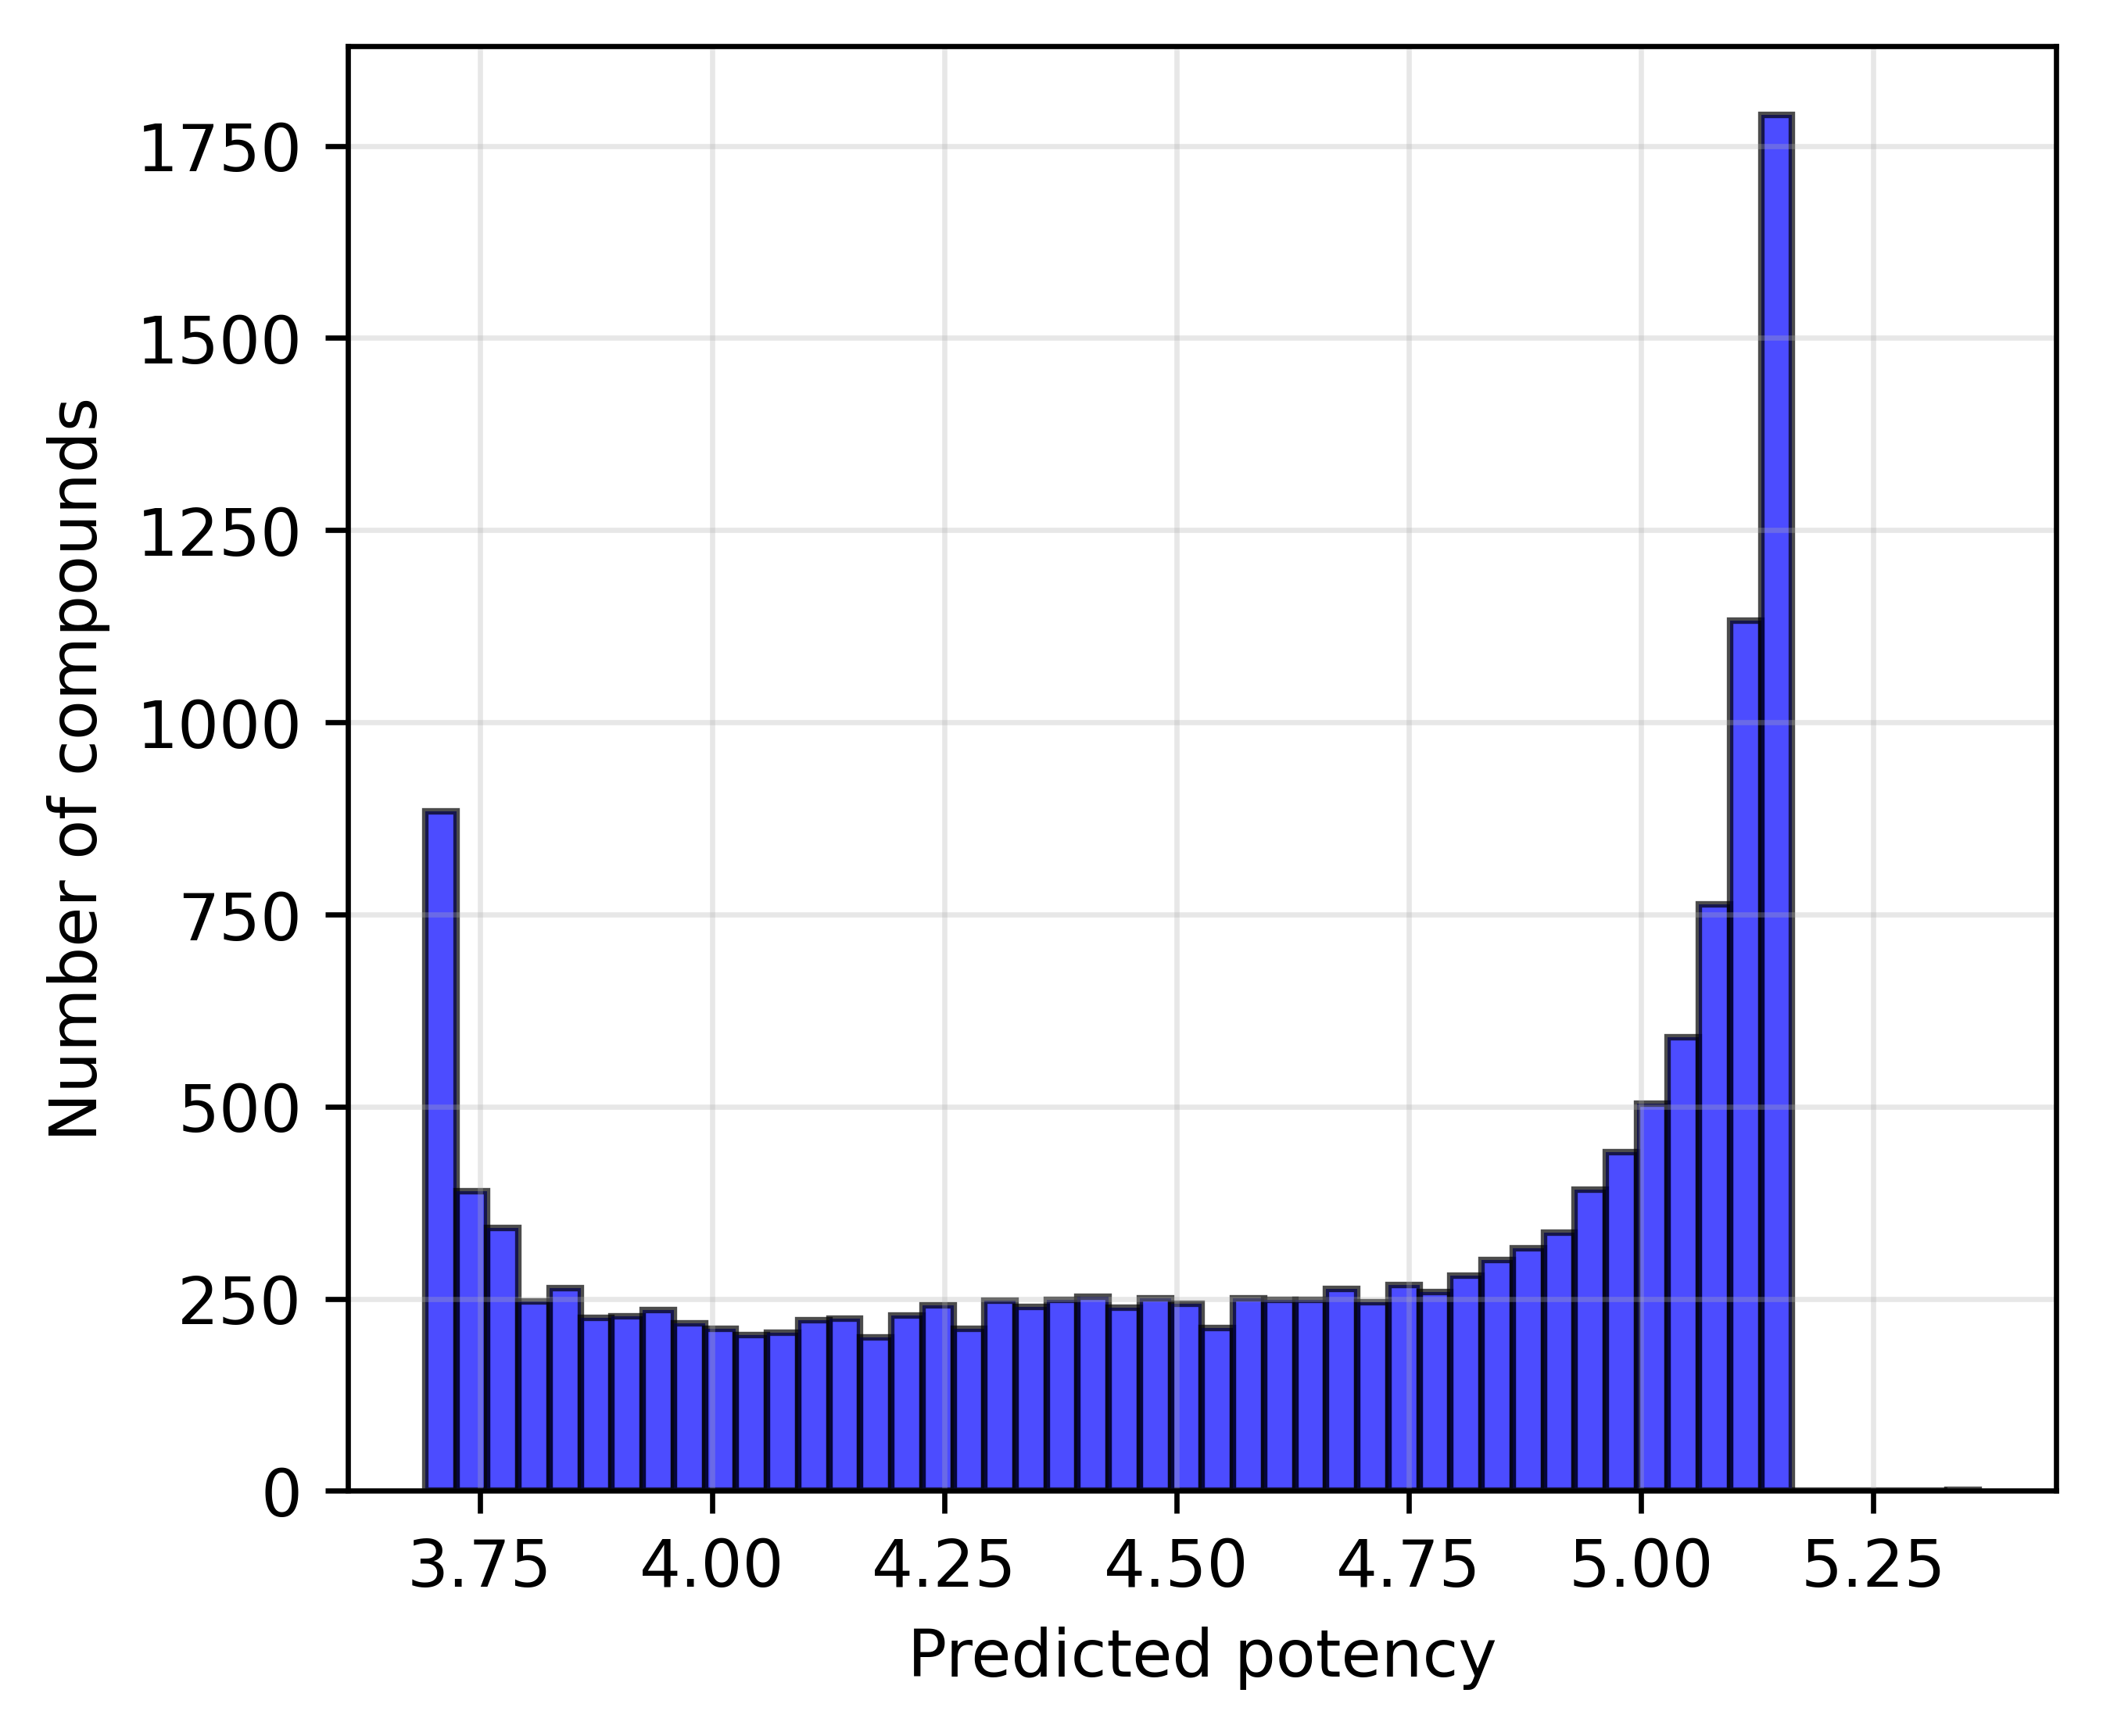

In [95]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/YersiniaPestis_noDuplicates_validationLCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/YersiniaPestis_noDuplicates_validationLCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [96]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 4724 compounds


In [97]:
LCAntibacterialsData_final = LCAntibacterialsData.iloc[idx].copy()
LCAntibacterialsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntibacterialsData_final = LCAntibacterialsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntibacterialsData_final

,SMILES,pPotency_prediction,clogP


### Top 20 compounds with higher pPPotency

In [98]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.15
Highest predicted pPotency: 5.36
Range of top 20: 5.15 - 5.36


In [99]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntibacterialsData_top20 = LCAntibacterialsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntibacterialsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntibacterialsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntibacterialsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntibacterialsData_top20 = LCAntibacterialsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntibacterialsData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.149
  IC50:        7.100e-06 M  (7100.24 nM)

Best Values (1st ranked compound):
  pPotency:    5.363
  IC50:        4.332e-06 M  (4332.07 nM)
Range for Top 20 Compounds:
pPotency Range:  5.149 - 5.363

IC50 Range (M):  7.100e-06 - 4.332e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
15414,1,Cc1ccc(C2=NN(C(=S)Nc3ccccc3)C(c3cccc([N+](=O)[...,5.363,4.332e-06
9214,2,COc1cccc(CN(c2ccc(F)c(F)c2)S(=O)(=O)c2cccn3c(C...,5.149,7.100e-06
11870,3,Cc1ccc(Nc2nc(Nc3ccccc3)c3cnn(C)c3n2)cc1Cl,5.149,7.100e-06
12514,4,O=C(COc1ccccc1F)Nc1cccc(-c2nc3ccccc3o2)c1,5.149,7.100e-06
11488,5,CCOC(=O)CSc1nnc(CNC(=O)c2cccs2)n1-c1cccc(C(F)(...,5.149,7.100e-06
14090,6,Cc1ccc(-c2n[nH]c3c2C(c2ccc(OC(=O)N4CCOCC4)cc2)...,5.149,7.100e-06
12041,7,Cc1ccc(Nc2nc(Nc3ccc(Cl)cc3)c3cnn(C)c3n2)cc1C,5.149,7.100e-06
6897,8,CC(C)c1ccc(NC(=O)Cn2nc(-c3ccc(Cl)cc3)ccc2=O)cc1,5.149,7.100e-06
9392,9,O=C(Cc1ccccc1)Nc1nc(-c2ccc3c(c2)OCCO3)cs1,5.149,7.100e-06
8328,10,O=C(CSc1ccc2nnc(-c3ccccc3)n2n1)N1CCc2ccccc21,5.149,7.100e-06


In [100]:
LCAntibacterialsData_top20.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntibacterialsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_predictedCompounds_LCDataset.svg


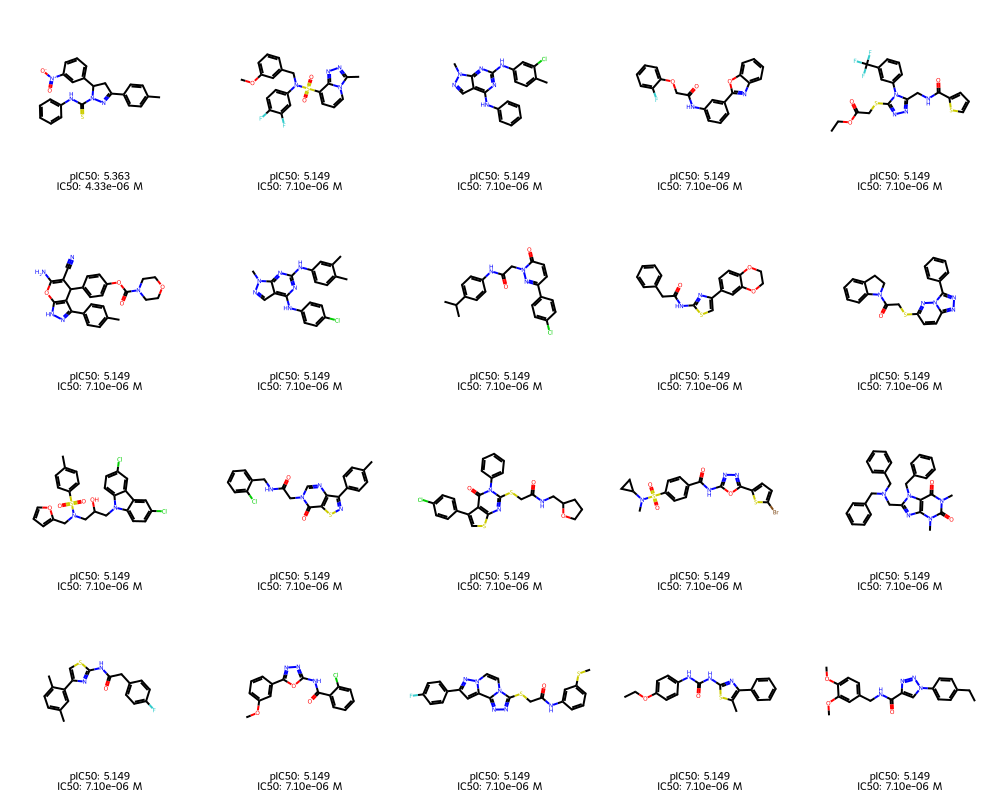

In [101]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntibacterialsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in LCAntibacterialsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/YersiniaPestis_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/YersiniaPestis_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 

### 2.3 Discovery of new hits specific to all viruses (data source ChemDiv antibiotics)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library ("ChemDiv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [102]:
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antibacterial_gramm_negative_12510.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiBioticData = pd.DataFrame(records)

print(f"Original ChemDiv data shape: {ChemDivAntiBioticData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiBioticData['Canonical_SMILES'] = ChemDivAntiBioticData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiBioticData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiBioticData_filtered = ChemDivAntiBioticData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiBioticData = ChemDivAntiBioticData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiBioticData.shape}")
print(f"Removed {ChemDivAntiBioticData_filtered.shape[0] - ChemDivAntiBioticData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiBioticData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiBioticData

Original ChemDiv data shape: (12510, 16)
Number of unique SMILES in training set: 92
Filtered ChemDiv data shape for validation: (12510, 16)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 12510


,IDNUMBER,STEREO_COMMENTS,SMILE,LOGP,LOGD,LOGSW,N_ROTB,N_CHIRALS,H_ACCEPTORS,H_DONORS,PSA,WEIGHT_AVAILABLE1,CHEMNAME,SMILES,SALTDATA,SALTDATA_MOLWEIGHT
0,000L-0380,ACHIRAL,[O-][N+](c(cc1)ccc1C(Oc(cc1)ccc1-c1ccccc1)=O)=O,4.934,4.934,-5.149,5.000,0.000e+00,7.000,0.000e+00,53.726,34,"[1,1'-biphenyl]-4-yl 4-nitrobenzoate",O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,NaN,NaN
1,0071-0020,ACHIRAL,Cn(cc1)nc1C(N/N=C/c(cc1)ccc1OC)=O,1.256,1.255,-1.843,5.000,0.000e+00,5.000,1.000,57.790,12,N'-[(4-methoxyphenyl)methylidene]-1-methyl-1H-...,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,NaN,NaN
2,0080-0039,RACEMIC MIXTURE,CC1(C)OC1COC(c(cc(cco1)c1c1)c1O1)=CC1=O,2.481,2.481,-3.143,3.000,1.000,6.000,0.000e+00,44.076,113,"5-[(3,3-dimethyloxiran-2-yl)methoxy]-7H-furo[3...",CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,NaN,NaN
3,0083-0046,ACHIRAL,O=C(Cc1ccccc1)c(cc1)ccc1-c1ccccc1,4.779,4.779,-5.194,4.000,0.000e+00,2.000,0.000e+00,12.942,985,"1-([1,1'-biphenyl]-4-yl)-2-phenylethan-1-one",O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,NaN,NaN
4,0089-0027,ACHIRAL,O=C(c1cccc(C(Nc(cc2)ccc2Oc2ccccc2)=O)c1)Nc(cc1...,7.293,7.292,-6.294,10.000,0.000e+00,6.000,2.000,59.916,4,"N~1~,N~3~-bis(4-phenoxyphenyl)benzene-1,3-dica...",O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12505,Z601-8334,ACHIRAL,Nc1nc(Nc(cccc2)c2F)nc2ccccc12,3.415,3.097,-3.641,2.000,0.000e+00,2.000,3.000,48.570,460,"N~2~-(2-fluorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12506,Z601-8612,ACHIRAL,CNc1nc(Nc(cccc2)c2F)nc2ccccc12,4.019,3.229,-4.160,3.000,0.000e+00,2.000,2.000,39.170,841,N~2~-(2-fluorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2F)nc2ccccc12,HCl,36.461
12507,Z601-8674,ACHIRAL,Nc1nc(Nc(cccc2)c2Cl)nc2ccccc12,3.686,3.268,-3.905,2.000,0.000e+00,2.000,3.000,48.570,336,"N~2~-(2-chlorophenyl)quinazoline-2,4-diamine",Nc1nc(Nc2ccccc2Cl)nc2ccccc12,NaN,NaN
12508,Z601-9100,ACHIRAL,CNc1nc(Nc(cccc2)c2Cl)nc2ccccc12,4.290,3.350,-4.279,3.000,0.000e+00,2.000,2.000,39.170,558,N~2~-(2-chlorophenyl)-N~4~-methylquinazoline-2...,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,HCl,36.461


In [103]:
print("\nComputing MACAW embeddings")
X1_lib = mcw.transform(smi_lib)
print(f"Embedding shape: {X1_lib.shape}")


Computing MACAW embeddings
Embedding shape: (12510, 31)


In [104]:
print("Generating predictions")
Y1_lib_pred = regr_pred.predict(X1_lib)
print(f"Predictions shape: {Y1_lib_pred.shape}")

Generating predictions
Predictions shape: (12510,)


In [105]:
ChemDivAntiBioticData_predicted = ChemDivAntiBioticData.copy()
ChemDivAntiBioticData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiBioticData_predicted['IC50 (M)'] = 10 ** (-ChemDivAntiBioticData_predicted['pPotency_prediction'])

ChemDivAntiBioticData_predicted = ChemDivAntiBioticData_predicted.filter(
    items=["SMILES", "pPotency_prediction", "IC50 (M)"]
)

ChemDivAntiBioticData_predicted.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiBioticData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiBioticData_predicted

,SMILES,pPotency_prediction,IC50 (M)
0,O=C(Oc1ccc(-c2ccccc2)cc1)c1ccc([N+](=O)[O-])cc1,4.035,9.218e-05
1,COc1ccc(/C=N/NC(=O)c2ccn(C)n2)cc1,4.046,9.004e-05
2,CC1(C)OC1COc1cc(=O)oc2cc3occc3cc12,3.691,2.035e-04
3,O=C(Cc1ccccc1)c1ccc(-c2ccccc2)cc1,3.874,1.337e-04
4,O=C(Nc1ccc(Oc2ccccc2)cc1)c1cccc(C(=O)Nc2ccc(Oc...,4.572,2.681e-05
...,...,...,...
12505,Nc1nc(Nc2ccccc2F)nc2ccccc12,4.288,5.149e-05
12506,CNc1nc(Nc2ccccc2F)nc2ccccc12,4.616,2.423e-05
12507,Nc1nc(Nc2ccccc2Cl)nc2ccccc12,4.078,8.363e-05
12508,CNc1nc(Nc2ccccc2Cl)nc2ccccc12,4.488,3.248e-05


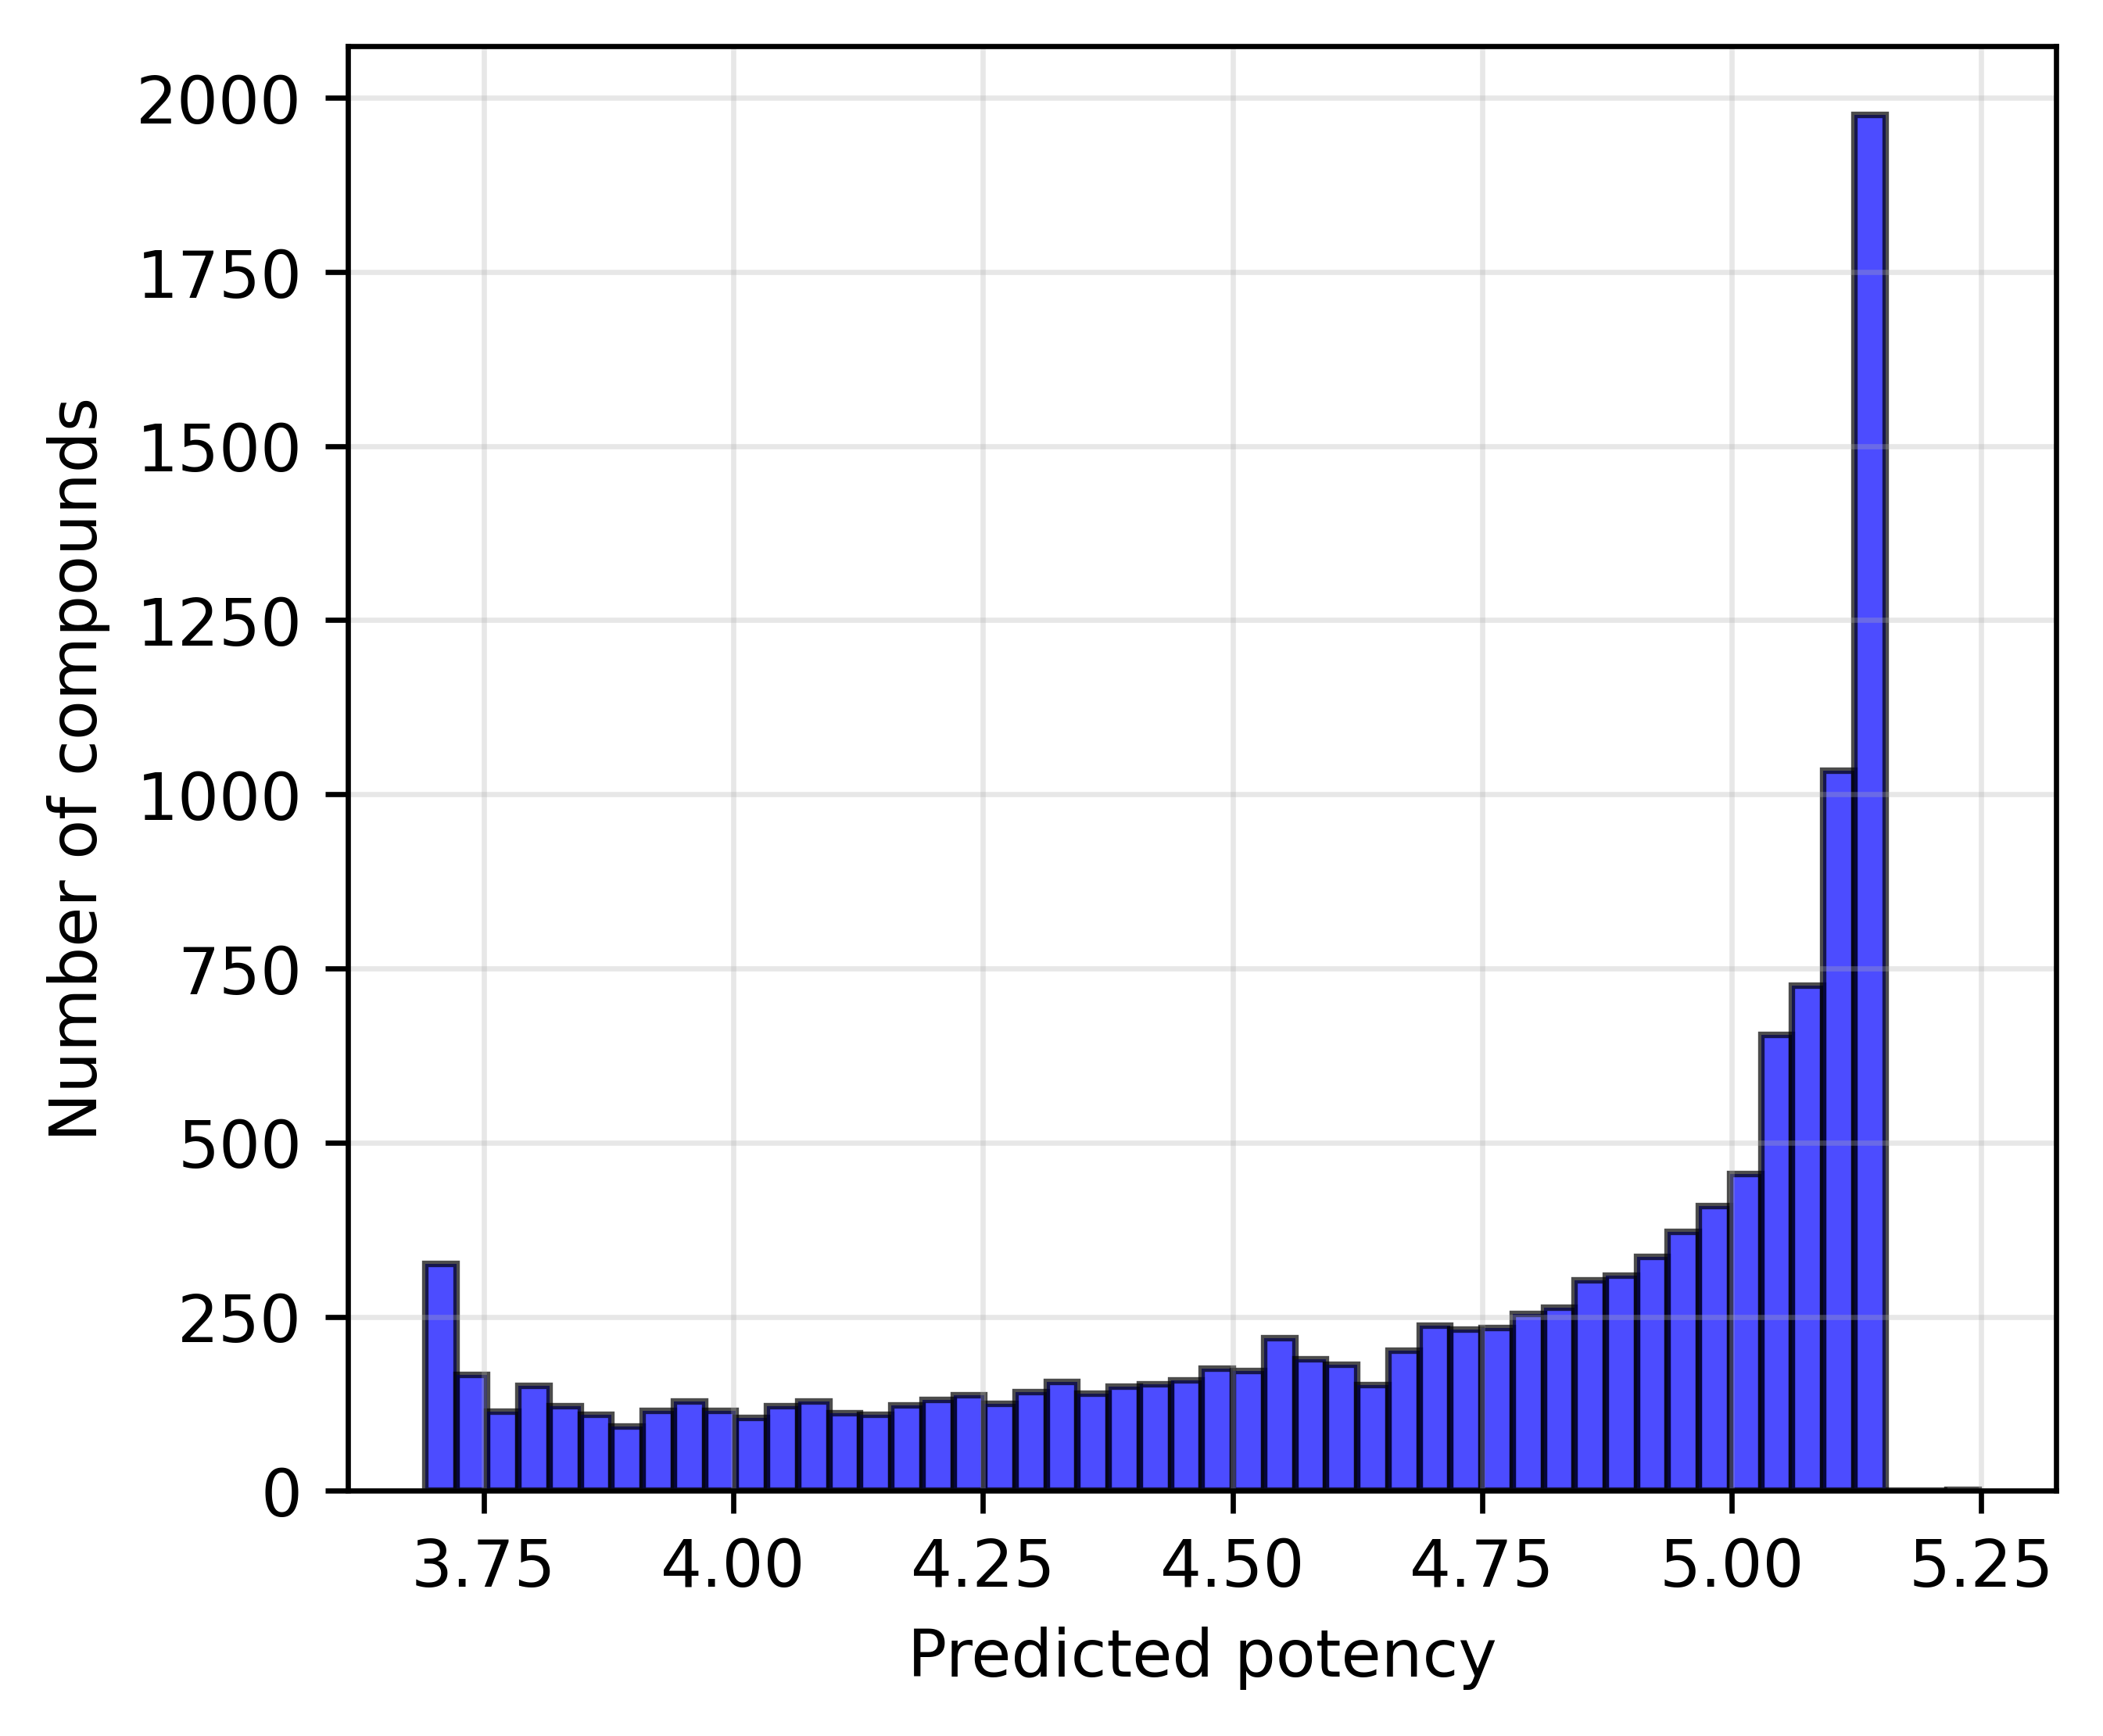

In [106]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + '/YersiniaPestis_noDuplicates_validationChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + '/YersiniaPestis_noDuplicates_validationChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [107]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 0 compounds
Low priority (5 ≤ pPotency < 6): 4825 compounds


In [108]:
ChemDivAntiBioticData_final = ChemDivAntiBioticData.iloc[idx].copy()
ChemDivAntiBioticData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiBioticData_final = ChemDivAntiBioticData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiBioticData_final

,SMILES,pPotency_prediction


### Top 20 compounds with higher pPPotency

In [109]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.15
Highest predicted pPotency: 5.25
Range of top 20: 5.15 - 5.25


In [110]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiBioticData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiBioticData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiBioticData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*50)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*50)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiBioticData_top20 = ChemDivAntiBioticData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiBioticData_top20

--------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
--------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.149
  IC50:        7.100e-06 M  (7100.24 nM)

Best Values (1st ranked compound):
  pPotency:    5.247
  IC50:        5.658e-06 M  (5658.00 nM)
Range for Top 20 Compounds:
pPotency Range:  5.149 - 5.247

IC50 Range (M):  7.100e-06 - 5.658e-06


,Rank,SMILES,pPotency_prediction,IC50 (M)
2528,1,COc1ccc(OC)c(C2CC(c3ccccc3)=NN2C(=S)Nc2ccccc2)c1,5.247,5.658e-06
1203,2,C/C(=N\Nc1nc(-c2ccc([N+](=O)[O-])cc2)cs1)c1cc2...,5.149,7.100e-06
2067,3,CCOC(=O)C1=C(C)N=c2s/c(=C\c3ccc(SC)cc3)c(=O)n2...,5.149,7.100e-06
4160,4,COc1c(Cl)cc(Cl)cc1/C=N/NC(=O)c1ccc(NC(=O)c2ccc...,5.149,7.100e-06
2026,5,CCOC(=O)C1=C(C)N=c2s/c(=C\c3ccc(F)cc3)c(=O)n2C...,5.149,7.100e-06
4587,6,COc1ccc2c(c1)c(CC(=O)NCCOc1ccc(Cl)cc1)c(C)n2C(...,5.149,7.100e-06
3042,7,CC(C)(C)c1ccc(C2C(C(=O)c3ccc(F)cc3)=C(O)C(=O)N...,5.149,7.100e-06
8683,8,Cc1ccc(NC(=O)N2CCC3(CC2)Nc2cc(F)ccc2-n2cccc23)...,5.149,7.100e-06
7566,9,COc1cc(OC)cc(C(=O)Nc2nc(CC(=O)NCCc3ccccc3OC)cs...,5.149,7.100e-06
887,10,CCOC(=O)C1=C(C)N=c2s/c(=C\c3ccccc3)c(=O)n2C1c1...,5.149,7.100e-06


In [111]:
ChemDivAntiBioticData_top20.to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiBioticData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "YersiniaPestis/YersiniaPestis_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_predictedCompounds_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/YersiniaPestis/YersiniaPestis_noDuplicates_predictedCompounds_ChemDivDataset.svg


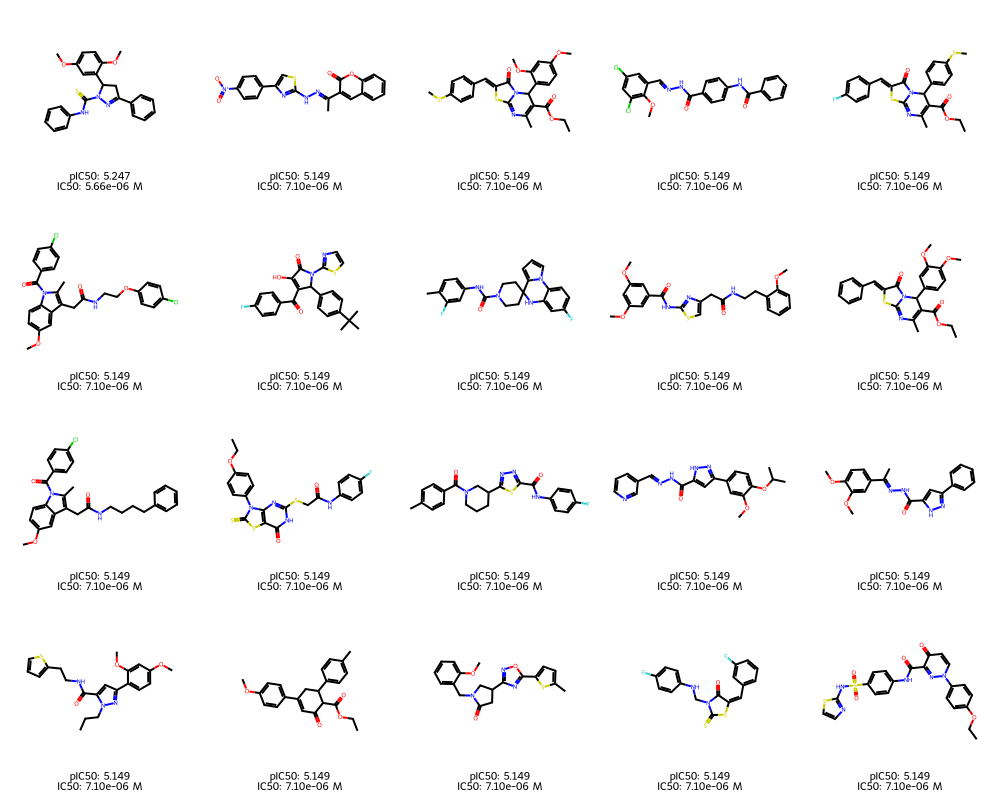

Partition 2/10
  Fold 2 - Train MAE: 0.45, Test MAE: 0.99
Partition 5/10
  Fold 5 - Train MAE: 0.57, Test MAE: 0.79
Partition 8/10
  Fold 8 - Train MAE: 0.88, Test MAE: 0.69
Partition 4/10
Not enough Nldnmk, n_components has been set to 34
  Fold 4 - Train MAE: 1.09, Test MAE: 0.67
Partition 7/10
Not enough Nldnmk, n_components has been set to 34
  Fold 7 - Train MAE: 0.80, Test MAE: 1.11
Partition 1/10
  Fold 1 - Train MAE: 0.40, Test MAE: 0.84
Partition 6/10
  Fold 6 - Train MAE: 0.39, Test MAE: 0.60
Partition 9/10
  Fold 9 - Train MAE: 0.52, Test MAE: 1.22
Partition 3/10
Not enough Nldnmk, n_components has been set to 33
  Fold 3 - Train MAE: 0.58, Test MAE: 0.57
Partition 6/10
Not enough Nldnmk, n_components has been set to 33
  Fold 6 - Train MAE: 0.54, Test MAE: 0.30
Partition 10/10
Not enough Nldnmk, n_components has been set to 32
  Fold 10 - Train MAE: 0.51, Test MAE: 0.48
Partition 4/10
  Fold 4 - Train MAE: 0.38, Test MAE: 0.76
Partition 1/10
Not enough Nldnmk, n_components 

In [112]:
# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiBioticData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiBioticData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + '/YersiniaPestis_noDuplicates_predictedCompounds_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + '/YersiniaPestis_noDuplicates_predictedCompounds_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img) 